## Librerias

In [3]:
import pandas as pd
import numpy as np
import matplotlib as plt
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import re

## EDA

### Lectura del dataset

In [4]:
data = pd.read_csv("datamedio.csv")
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 511 entries, 0 to 510
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Marca temporal   511 non-null    str  
 1   Correo           511 non-null    str  
 2   Semestre         511 non-null    str  
 3   Carrera          511 non-null    str  
 4   Regular          482 non-null    str  
 5   Ciudad           511 non-null    str  
 6   Hermanos         482 non-null    str  
 7   Marca            511 non-null    str  
 8   Modelo           504 non-null    str  
 9   Capacidad        511 non-null    str  
 10  Metodo_pago      511 non-null    str  
 11  Tiempo           511 non-null    str  
 12  Estado           511 non-null    str  
 13  Gender           511 non-null    str  
 14  Trabajo          511 non-null    str  
 15  Edad             511 non-null    str  
 16  Telefono_futuro  481 non-null    str  
dtypes: str(17)
memory usage: 68.0 KB


In [5]:
data.head()

,Marca temporal,Correo,Semestre,Carrera,Regular,Ciudad,Hermanos,Marca,Modelo,Capacidad,Metodo_pago,Tiempo,Estado,Gender,Trabajo,Edad,Telefono_futuro
0,03/09/2026 17:30,fespinozagarcia0105@gmail.com,Tercero,Ciencia de Datos,NaN,Estado de México,NaN,Honor,Honor X7a,128 GB,Plan,Entre 2 y 3 años,Nuevo,Mujer,Sí,21,NaN
1,03/09/2026 18:02,gisellemerino2702@gmail.com,Tercero,Ciencia de Datos,NaN,Estado de México,NaN,Apple,iPhone 15 pro max,256 GB,Prepago,Entre 6 meses y 1 año,Nuevo,Mujer,No,21,NaN
2,03/09/2026 18:19,mildredcaravantes@gmail.com,Primero,Ciencia de Datos,NaN,Estado de México,NaN,Apple,iPhone 16 pro max,256 GB,Plan,Entre 1 y 2 años,Nuevo,Mujer,No,20,NaN
3,03/09/2026 18:37,garcia.hernandez.edgar.alessandro@gmail.com,Tercero,Ciencia de Datos,NaN,CDMX,NaN,Apple,iPhone 16 pro max,256 GB,Plan,Entre 1 y 2 años,Nuevo,Hombre,No,19,NaN
4,03/09/2026 20:56,diegobus022@gmail.com,Tercero,Ciencia de Datos,NaN,Otro,NaN,Apple,iPhone 13 pro max,512 GB,Prepago,Entre 1 y 2 años,Segunda mano,Hombre,No,19,NaN


In [6]:
data.describe()

,Marca temporal,Correo,Semestre,Carrera,Regular,Ciudad,Hermanos,Marca,Modelo,Capacidad,Metodo_pago,Tiempo,Estado,Gender,Trabajo,Edad,Telefono_futuro
count,511,511,511,511,482,511,482,511,504,511,511,511,511,511,511,511,481
unique,380,511,8,4,2,18,2,13,273,7,2,5,2,2,2,8,15
top,03/12/2026 15:21,fespinozagarcia0105@gmail.com,Cuarto,Ingeniería en Sistemas,Sí,CDMX,Sí,Apple,iPhone 14,256 GB,Plan,Entre 1 y 2 años,Nuevo,Hombre,No,19,Samsung
freq,13,1,113,267,290,275,410,152,15,194,305,163,436,374,341,131,180


### Dimensiones

In [7]:
print("Dimensiones del dataset:", data.shape)
print("Número de filas:", data.shape[0])
print("Número de columnas:", data.shape[1])

Dimensiones del dataset: (511, 17)
Número de filas: 511
Número de columnas: 17


In [8]:
print(data.notnull().sum())

Marca temporal     511
Correo             511
Semestre           511
Carrera            511
Regular            482
Ciudad             511
Hermanos           482
Marca              511
Modelo             504
Capacidad          511
Metodo_pago        511
Tiempo             511
Estado             511
Gender             511
Trabajo            511
Edad               511
Telefono_futuro    481
dtype: int64


In [9]:
print(data["Modelo"].value_counts())

Modelo
iPhone 14           15
iPhone 13           13
iPhone 11           11
Galaxy A54          11
iPhone 12           10
                    ..
Xiaomi 14 Ultra      1
GalaxyA55            1
Xiaomi 15 ultra      1
S23 Ultra            1
g71 5G               1
Name: count, Length: 273, dtype: int64


### Limpieza de datos

In [10]:
print(data.columns)
data["Semestre"]=data["Semestre"].map({
    "Primero":1,
    "Segundo":2,
    "Tercero":3,
    "Cuarto":4,
    "Quinto":5,
    "Sexto":6,
    "Septimo":7,
    "Octavo":8
})
data["Carrera"]=data["Carrera"].map({
    "Ciencia de Datos":1,
    "Inteligencia Artificial":2,
    "Ingeniería en Sistemas":3
})
data["Regular"]=data["Regular"].map({
    "No":0,
    "Sí":1
})
data["Hermanos"]=data["Hermanos"].map({
    "No":0,
    "Sí":1
})
data["Capacidad"]=data["Capacidad"].map({
    "256 GB":256,
    "128 GB":128,
    "64 GB":64,
    "512 GB":512,
    "32 GB":32,
    "1 TB":1000,
    "2 TB":2000
})
data["Metodo_pago"]=data["Metodo_pago"].map({
    "Plan":1,
    "Prepago":0
})
data["Tiempo"]=data["Tiempo"].map({
    "Menos de 6 meses":0,
    "Entre 6 meses y 1 año":1,
    "Entre 1 y 2 años":2,
    "Entre 2 y 3 años":3,
    "Más de 3 años":4
})
data["Estado"]=data["Estado"].map({
    "Nuevo":1,
    "Segunda mano":0
})
data["Gender"]=data["Gender"].map({
    "Mujer":0,
    "Hombre":1
})
data["Trabajo"]=data["Trabajo"].map({
    "Sí":1,
    "No":0
})
data["Edad"]=data["Edad"].replace({
    "24 o más":24
})

def es_modelo_valido(modelo):
    """
    Determina si un modelo es válido (no contiene patrones problemáticos)
    """
    if pd.isna(modelo):
        return False
    
    modelo_str = str(modelo).lower().strip()
    
    # Lista de patrones inválidos
    patrones_invalidos = [
        'no especificado',
        'error',
        'none',
        'null',
        'n/a',
        'desconocido',
        'sin especificar',
        'sin modelo'
    ]
    
    # Verificar si contiene algún patrón inválido
    for patron in patrones_invalidos:
        if patron in modelo_str:
            return False
    
    # Verificar que no sea solo números o muy corto
    if re.match(r'^[\d\s]+$', modelo_str):
        return False
    
    if len(modelo_str) < 2:
        return False
    
    return True

# Aplicar filtro
print(f"Registros originales: {len(data)}")

# Identificar modelos inválidos
data['Modelo_valido'] = data['Modelo'].apply(es_modelo_valido)
modelos_invalidos = data[~data['Modelo_valido']]

print(f"\n📋 Modelos inválidos encontrados:")
print(modelos_invalidos[['Marca', 'Modelo']].value_counts().head(20))

# Filtrar solo modelos válidos
data = data[data['Modelo_valido']].copy()
data = data.drop('Modelo_valido', axis=1)

print(f"\n✅ Después de limpieza: {len(data)} registros")
print(f"❌ Eliminados: {len(data) - len(data)} registros")

# Limpiar el texto de los modelos válidos
def estandarizar_modelo(modelo):
    modelo = str(modelo).strip()
    # Eliminar paréntesis y su contenido
    modelo = re.sub(r'\s*\([^)]*\)', '', modelo)
    # Eliminar espacios extras
    modelo = ' '.join(modelo.split())
    return modelo

data['Modelo'] = data['Modelo'].apply(estandarizar_modelo)

# Guardar
data.to_csv("data_sin_errores.csv", index=False, encoding='utf-8-sig')
print("\n💾 Datos guardados en 'data_sin_errores.csv'")

Index(['Marca temporal', 'Correo', 'Semestre', 'Carrera', 'Regular', 'Ciudad',
       'Hermanos', 'Marca', 'Modelo', 'Capacidad', 'Metodo_pago', 'Tiempo',
       'Estado', 'Gender', 'Trabajo', 'Edad', 'Telefono_futuro'],
      dtype='str')
Registros originales: 511

📋 Modelos inválidos encontrados:
Marca    Modelo                     
Xiaomi   Redmi (no especificado)        2
Samsung  Galaxy (no especificado)       1
         Galaxy A (no especificado)     1
Xiaomi   De ayer (error)                1
         G4 (error)                     1
Honor    Iphone 16 pro max (error)      1
Xiaomi   MP4 OPPO (error)               1
         Mui (error)                    1
         Poco (no especificado)         1
Realme   Poco m5s (error)               1
Huawei   POCO (error)                   1
Oppo     CPH2175 (no especificado)      1
ZTE      BLADE (no especificado)        1
Huawei   Huawei (no especificado)       1
Xiaomi   Remi note (no especificado)    1
Name: count, dtype: int64

✅ Desp

In [11]:
data["Edad"].value_counts()

Edad
19    123
20    105
21     81
22     59
18     55
24     40
23     23
17      2
Name: count, dtype: int64

In [12]:
data

,Marca temporal,Correo,Semestre,Carrera,Regular,Ciudad,Hermanos,Marca,Modelo,Capacidad,Metodo_pago,Tiempo,Estado,Gender,Trabajo,Edad,Telefono_futuro
0,03/09/2026 17:30,fespinozagarcia0105@gmail.com,3.0,1.0,NaN,Estado de México,NaN,Honor,Honor X7a,128,1,3,1,0,1,21,NaN
1,03/09/2026 18:02,gisellemerino2702@gmail.com,3.0,1.0,NaN,Estado de México,NaN,Apple,iPhone 15 pro max,256,0,1,1,0,0,21,NaN
2,03/09/2026 18:19,mildredcaravantes@gmail.com,1.0,1.0,NaN,Estado de México,NaN,Apple,iPhone 16 pro max,256,1,2,1,0,0,20,NaN
3,03/09/2026 18:37,garcia.hernandez.edgar.alessandro@gmail.com,3.0,1.0,NaN,CDMX,NaN,Apple,iPhone 16 pro max,256,1,2,1,1,0,19,NaN
4,03/09/2026 20:56,diegobus022@gmail.com,3.0,1.0,NaN,Otro,NaN,Apple,iPhone 13 pro max,512,0,2,0,1,0,19,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
503,3/18/2026 15:12:40,angelurielmendozacruz@gmail.com,4.0,3.0,1.0,CDMX,1.0,Apple,iPhone 14,128,0,1,1,1,1,20,Apple
504,3/13/2026 19:26:09,fafa.marquezmarcos@gmail.com,4.0,3.0,1.0,CDMX,1.0,Xiaomi,Xiaomi 15 ultra,512,1,1,1,1,0,19,Xiaomi
505,03/12/2026 15:20,huitzil.cruz.omaralejandro@gmail.com,2.0,1.0,1.0,Estado de México,1.0,Samsung,S23 Ultra,256,1,3,1,1,0,18,Apple
506,3/18/2026 16:05:40,gonzalez.leonardo.vv06@gmail.com,3.0,1.0,1.0,Estado de México,1.0,Motorola,g71 5G,128,1,3,1,1,0,20,Motorola


In [13]:
# Convertir a DataFrame y guardar como archivo de texto
data["Modelo"].value_counts().to_csv('conteo_modelos.txt', sep='\t', header=True)

In [14]:
data[["Marca", "Tiempo", "Modelo","Capacidad"]].value_counts().to_csv(
    "conteo.txt", sep="\t", header=True
)

── Distribución por género ──
  1: 355 estudiantes (72.7%)
  0: 133 estudiantes (27.3%)


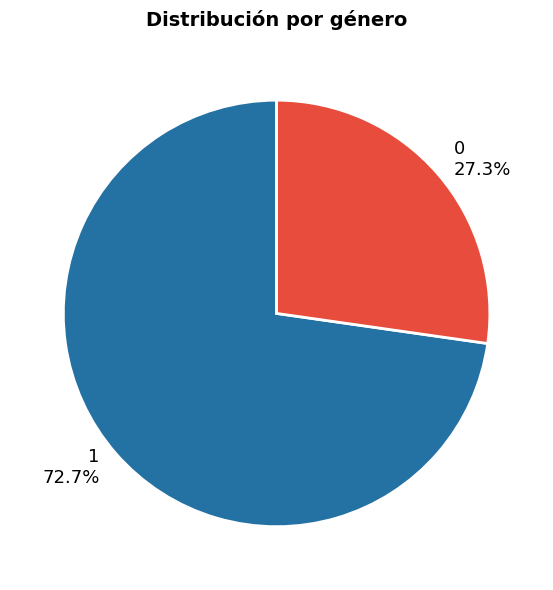

In [15]:
# Distribución por género
gen_counts = data["Gender"].value_counts()
gen_pct    = (gen_counts / len(data) * 100).round(1)

print("── Distribución por género ──")
for g, n, p in zip(gen_counts.index, gen_counts.values, gen_pct.values):
    print(f"  {g}: {n} estudiantes ({p}%)")

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(gen_counts.values,
       labels=[f"{g}\n{p}%" for g, p in zip(gen_counts.index, gen_pct.values)],
       colors=["#2471A3", "#E74C3C"],
       startangle=90,
       wedgeprops=dict(linewidth=2, edgecolor="white"),
       textprops=dict(fontsize=13))
ax.set_title("Distribución por género", fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("genero_pie.png", bbox_inches='tight', dpi=200)
plt.show()

DESBALANCE POR CARRERA:
Carrera
3.0    256
1.0    159
2.0     71
Name: count, dtype: int64


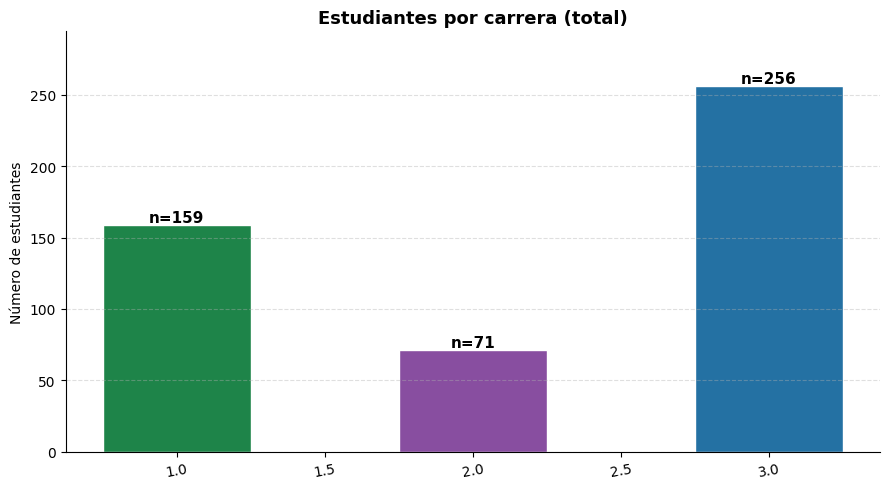

In [16]:
# ── Distribución por carrera (referencia para normalización) ──
print("DESBALANCE POR CARRERA:")
print(data["Carrera"].value_counts())

# ── Gráfica con las 4 carreras (ANTES de excluir) ────────────
carr_counts  = data["Carrera"].value_counts()
colores_carr = ["#2471A3", "#1E8449", "#884EA0", "#B7950B"]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(carr_counts.index, carr_counts.values,
              color=colores_carr, edgecolor="white", width=0.5)

for bar, val in zip(bars, carr_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 2,
            f"n={val}", ha='center', fontsize=11, fontweight="bold")

ax.set_title("Estudiantes por carrera (total)", fontsize=13, fontweight="bold")
ax.set_ylabel("Número de estudiantes")
ax.set_ylim(0, carr_counts.max() * 1.15)
ax.tick_params(axis='x', rotation=10)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("barras_carrera.png", bbox_inches='tight', dpi=150)
plt.show()

DESBALANCE POR CARRERA:
Carrera
3.0    256
1.0    159
2.0     71
Name: count, dtype: int64


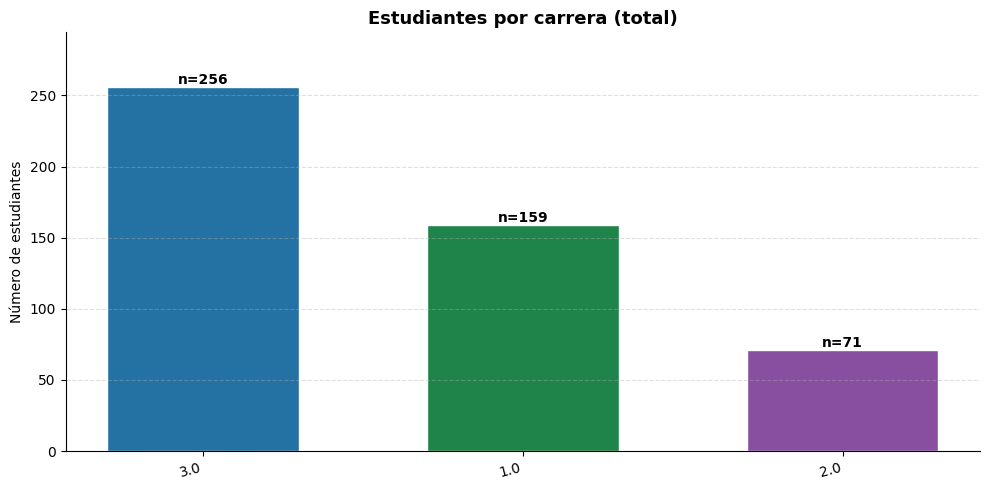

Valores únicos en Semestre: [ 3.  1.  6.  5.  4. nan  2.  8.]


In [17]:
# ── Distribución por carrera (referencia para normalización) ──
print("DESBALANCE POR CARRERA:")
print(data["Carrera"].value_counts())

# ── Gráfica con las carreras (ANTES de excluir) ────────────
# Obtener todas las carreras
carr_counts = data["Carrera"].value_counts()

# Crear una paleta de colores dinámica
colores_carr = ["#2471A3", "#1E8449", "#884EA0", "#B7950B", "#D35400", "#E67E22"]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(len(carr_counts)), carr_counts.values,
              color=colores_carr[:len(carr_counts)], edgecolor="white", width=0.6)

# Etiquetas
ax.set_xticks(range(len(carr_counts)))
ax.set_xticklabels(carr_counts.index, rotation=15, ha='right')

for bar, val in zip(bars, carr_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 2,
            f"n={val}", ha='center', fontsize=10, fontweight="bold")

ax.set_title("Estudiantes por carrera (total)", fontsize=13, fontweight="bold")
ax.set_ylabel("Número de estudiantes")
ax.set_ylim(0, carr_counts.max() * 1.15)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("barras_carrera.png", bbox_inches='tight', dpi=150)
plt.show()

# ── Distribución por semestre ─────────────────────────────────
# Orden correcto de los semestres en español
orden_semestre = ["Primero", "Segundo", "Tercero", "Cuarto", 
                  "Quinto", "Sexto", "Séptimo", "Octavo"]

# Verificar que la columna existe
if "Semestre" not in data.columns:
    print("Columnas disponibles:", data.columns.tolist())
else:
    # Contar y reordenar
    sem_counts = data["Semestre"].value_counts().reindex(orden_semestre).fillna(0)
    
    # Filtrar solo los que tienen valores > 0
    sem_counts = sem_counts[sem_counts > 0]
    
    if len(sem_counts) == 0:
        print("Valores únicos en Semestre:", data["Semestre"].unique())
    else:
        fig, ax = plt.subplots(figsize=(12, 6))
        bars = ax.bar(range(len(sem_counts)), sem_counts.values,
                      color="#2471A3", edgecolor="white", width=0.6)
        
        # Etiquetas personalizadas
        ax.set_xticks(range(len(sem_counts)))
        ax.set_xticklabels(sem_counts.index, rotation=45, ha='right')
        
        for bar, val in zip(bars, sem_counts.values):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.5,
                    f"n={int(val)}", ha='center', fontsize=9, fontweight="bold")
        
        ax.set_title("Estudiantes por semestre", fontsize=13, fontweight="bold")
        ax.set_ylabel("Número de estudiantes")
        
        # Usar max() seguro
        max_val = sem_counts.max()
        if pd.notna(max_val) and max_val > 0:
            ax.set_ylim(0, max_val * 1.15)
        else:
            ax.set_ylim(0, 1)
            
        ax.spines[['top', 'right']].set_visible(False)
        ax.grid(axis='y', linestyle='--', alpha=0.4)
        plt.tight_layout()
        plt.savefig("barras_semestre.png", bbox_inches='tight', dpi=150)
        plt.show()
        
        # Mostrar estadísticas
        print("\n📊 Distribución por semestre:")
        for sem, count in sem_counts.items():
            print(f"  {sem}: {count} estudiantes ({count/len(data)*100:.1f}%)")

In [18]:
# Asumiendo que 'data' es tu DataFrame original
# Primero, creamos una función para clasificar por gama
def clasificar_gama(row):
    """
    Clasifica el dispositivo en ALTA, MEDIA o BAJA gama basado en la Marca y Modelo.
    """
    marca = str(row['Marca']).lower()
    modelo = str(row['Modelo']).lower()

    # --- GAMA ALTA (Precio de referencia: +15,000 MXN) ---
    if marca == 'apple':
        # Cualquier iPhone es considerado alta gama
        return 'ALTA'
    if marca == 'samsung' and ('s' in modelo or 'ultra' in modelo or 'z flip' in modelo):
        # Samsung: Serie S, Ultra o Z Flip
        return 'ALTA'
    if marca == 'google' and 'pixel' in modelo:
        # Google Pixel
        return 'ALTA'
    if marca == 'xiaomi' and ('ultra' in modelo or 'pro' in modelo and '14' in modelo or '15' in modelo):
        # Xiaomi: Solo los últimos modelos Ultra o Pro
        return 'ALTA'

    # --- GAMA MEDIA (Precio de referencia: 5,000 - 14,999 MXN) ---
    if marca in ['xiaomi', 'motorola', 'honor', 'oppo', 'realme', 'vivo']:
        if 'pro' in modelo or 'edge' in modelo or 'note' in modelo:
            return 'MEDIA'  # Modelos Pro, Edge o Note de estas marcas
        return 'MEDIA'      # La mayoría de estas marcas se consideran media gama
    if marca == 'samsung' and ('a' in modelo and not 's' in modelo):
        # Samsung: Serie A (pero no la S)
        return 'MEDIA'
    if marca == 'huawei':
        return 'MEDIA'

    # --- GAMA BAJA (Precio de referencia: < 5,000 MXN) ---
    # Todo lo que no ha sido clasificado como ALTA o MEDIA
    return 'BAJA'

# Aplicar la clasificación
data['Gama_Equipo'] = data.apply(clasificar_gama, axis=1)

# Mostrar la distribución
print("📊 Distribución por Gama de Equipo:")
print(data['Gama_Equipo'].value_counts())

# Opcional: Agregar una columna con el precio estimado basado en la gama
precios_estimados = {
    'ALTA': 18000,
    'MEDIA': 8000,
    'BAJA': 3500
}
data['Precio_Estimado_MXN'] = data['Gama_Equipo'].map(precios_estimados)

# Guardar el archivo con la nueva información
data.to_csv('data_con_gama.csv', index=False, encoding='utf-8-sig')
print("Archivo 'data_con_gama.csv' creado.")
print("\nEjemplo de los primeros registros:")
print(data[['Marca', 'Modelo', 'Gama_Equipo', 'Precio_Estimado_MXN']].head(10))

📊 Distribución por Gama de Equipo:
Gama_Equipo
MEDIA    234
ALTA     220
BAJA      34
Name: count, dtype: int64
Archivo 'data_con_gama.csv' creado.

Ejemplo de los primeros registros:
       Marca             Modelo Gama_Equipo  Precio_Estimado_MXN
0      Honor          Honor X7a       MEDIA                 8000
1      Apple  iPhone 15 pro max        ALTA                18000
2      Apple  iPhone 16 pro max        ALTA                18000
3      Apple  iPhone 16 pro max        ALTA                18000
4      Apple  iPhone 13 pro max        ALTA                18000
5     Xiaomi            14T Pro        ALTA                18000
6       Otra          Cubot P80        BAJA                 3500
7    Samsung         Galaxy A15       MEDIA                 8000
8   Motorola               G60s       MEDIA                 8000
10      Otra            Infinix        BAJA                 3500


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
import re
import warnings
warnings.filterwarnings('ignore')

# ── 1. VERIFICAR QUE LOS DATOS ESTÁN LISTOS ──────────────────────────────
print("📊 VERIFICACIÓN DE DATOS")
print("="*50)
print(f"Shape de datos: {data.shape}")
print(f"\nColumnas disponibles:\n{data.columns.tolist()}")
print(f"\nTipos de datos:")
print(data.dtypes)

# ── 2. SELECCIONAR VARIABLES NUMÉRICAS PARA PCA ──────────────────────────
print("\n" + "="*50)
print("📊 SELECCIÓN DE VARIABLES NUMÉRICAS")
print("="*50)

# Variables que ya convertiste a numéricas
variables_numericas = [
    'Semestre',      # 1-8
    'Carrera',       # 1-3
    'Regular',       # 0-1
    'Hermanos',      # 0-1
    'Capacidad',     # GB (32,64,128,256,512,1024,2048)
    'Metodo_pago',   # 0-1
    'Tiempo',        # 0-4 (años aproximados)
    'Estado',        # 0-1
    'Gender',        # 0-1
    'Trabajo',       # 0-1
    'Edad'           # Edad en años
]

# Verificar que todas las variables existen
variables_disponibles = [var for var in variables_numericas if var in data.columns]
variables_faltantes = [var for var in variables_numericas if var not in data.columns]

print(f"Variables disponibles: {len(variables_disponibles)}")
print(variables_disponibles)

if variables_faltantes:
    print(f"\n⚠️ Variables faltantes: {variables_faltantes}")

# ── 3. CREAR DATAFRAME CON VARIABLES NUMÉRICAS ───────────────────────────
df_numerico = data[variables_disponibles].copy()

# Convertir a numérico forzando errores
for col in df_numerico.columns:
    df_numerico[col] = pd.to_numeric(df_numerico[col], errors='coerce')

print(f"\nShape del DataFrame numérico: {df_numerico.shape}")
print(f"\nValores nulos por columna:")
print(df_numerico.isnull().sum())

# ── 4. MANEJAR VALORES NULOS ────────────────────────────────────────────
print("\n" + "="*50)
print("📊 MANEJO DE VALORES NULOS")
print("="*50)

# Ver porcentaje de nulos por columna
nulos_porcentaje = (df_numerico.isnull().sum() / len(df_numerico)) * 100
print("Porcentaje de nulos por columna:")
print(nulos_porcentaje[nulos_porcentaje > 0])

# Imputar valores nulos con la media
imputer = SimpleImputer(strategy='mean')
df_imputado = pd.DataFrame(
    imputer.fit_transform(df_numerico),
    columns=df_numerico.columns,
    index=df_numerico.index
)

print(f"\n✅ Nulos después de imputación: {df_imputado.isnull().sum().sum()}")

# ── 5. ESTANDARIZAR DATOS ────────────────────────────────────────────────
print("\n" + "="*50)
print("📊 ESTANDARIZACIÓN DE DATOS")
print("="*50)

scaler = StandardScaler()
df_estandarizado = scaler.fit_transform(df_imputado)
df_estandarizado = pd.DataFrame(
    df_estandarizado,
    columns=df_imputado.columns,
    index=df_imputado.index
)

print("Estadísticas después de estandarizar:")
print(df_estandarizado.describe().round(3))

# ── 6. APLICAR PCA ──────────────────────────────────────────────────────
print("\n" + "="*50)
print("📊 APLICANDO PCA")
print("="*50)

# Aplicar PCA
pca = PCA()
componentes = pca.fit_transform(df_estandarizado)

# Crear DataFrame con los componentes
nombres_componentes = [f'PC{i+1}' for i in range(componentes.shape[1])]
df_componentes = pd.DataFrame(
    componentes,
    columns=nombres_componentes,
    index=df_imputado.index
)

print(f"Shape de los componentes: {df_componentes.shape}")
print(f"Número de componentes generados: {len(nombres_componentes)}")

# ── 7. ANALIZAR VARIANZA EXPLICADA ──────────────────────────────────────
print("\n" + "="*50)
print("📊 VARIANZA EXPLICADA")
print("="*50)

varianza_explicada = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

print("Varianza explicada por cada componente:")
print("-" * 40)
for i, (var, var_acum) in enumerate(zip(varianza_explicada, varianza_acumulada)):
    print(f"PC{i+1:2d}: {var:6.2%} | Acumulado: {var_acum:6.2%}")

print(f"\n📌 Para explicar el 80% de varianza: {np.argmax(varianza_acumulada >= 0.80) + 1 if any(varianza_acumulada >= 0.80) else len(varianza_acumulada)} componentes")
print(f"📌 Para explicar el 90% de varianza: {np.argmax(varianza_acumulada >= 0.90) + 1 if any(varianza_acumulada >= 0.90) else len(varianza_acumulada)} componentes")
print(f"📌 Para explicar el 95% de varianza: {np.argmax(varianza_acumulada >= 0.95) + 1 if any(varianza_acumulada >= 0.95) else len(varianza_acumulada)} componentes")

# ── 8. VISUALIZACIONES ──────────────────────────────────────────────────
print("\n" + "="*50)
print("📊 GENERANDO VISUALIZACIONES")
print("="*50)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gráfico de varianza explicada (Scree plot)
axes[0, 0].bar(range(1, len(varianza_explicada)+1), varianza_explicada, 
               alpha=0.6, color='steelblue', label='Individual')
axes[0, 0].plot(range(1, len(varianza_acumulada)+1), varianza_acumulada, 
                'ro-', linewidth=2, markersize=6, label='Acumulada')
axes[0, 0].axhline(y=0.95, color='g', linestyle='--', alpha=0.7, label='95%')
axes[0, 0].axhline(y=0.90, color='orange', linestyle='--', alpha=0.7, label='90%')
axes[0, 0].axhline(y=0.80, color='red', linestyle='--', alpha=0.7, label='80%')
axes[0, 0].set_xlabel('Componente Principal')
axes[0, 0].set_ylabel('Varianza Explicada')
axes[0, 0].set_title('Scree Plot - Varianza Explicada por Componente', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xticks(range(1, len(varianza_explicada)+1))

# Matriz de correlación
corr_matrix = df_imputado.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, ax=axes[0, 1], square=True, cbar_kws={"shrink": 0.8})
axes[0, 1].set_title('Matriz de Correlación entre Variables', fontsize=12, fontweight='bold')

# Carga de variables en PC1 y PC2
loadings = pd.DataFrame(
    pca.components_[:2].T,
    columns=['PC1', 'PC2'],
    index=df_imputado.columns
)

# Graficar cargas
axes[1, 0].axhline(0, color='gray', linewidth=0.5, linestyle='--')
axes[1, 0].axvline(0, color='gray', linewidth=0.5, linestyle='--')

for i, var in enumerate(loadings.index):
    axes[1, 0].arrow(0, 0, loadings.iloc[i, 0], loadings.iloc[i, 1],
                     head_width=0.03, head_length=0.03, fc='blue', ec='blue', alpha=0.7)
    axes[1, 0].text(loadings.iloc[i, 0]*1.1, loadings.iloc[i, 1]*1.1, 
                    var, fontsize=9, fontweight='bold')

# Ajustar límites
max_loading = max(abs(loadings.values).max(), 0.5)
axes[1, 0].set_xlim(-max_loading*1.2, max_loading*1.2)
axes[1, 0].set_ylim(-max_loading*1.2, max_loading*1.2)
axes[1, 0].set_xlabel(f'PC1 ({varianza_explicada[0]:.1%})')
axes[1, 0].set_ylabel(f'PC2 ({varianza_explicada[1]:.1%})')
axes[1, 0].set_title('Carga de Variables en PC1 y PC2', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Scatter plot de las primeras dos componentes
scatter = axes[1, 1].scatter(df_componentes['PC1'], df_componentes['PC2'], 
                            alpha=0.6, c=df_componentes['PC1'], cmap='viridis', 
                            s=30, edgecolors='black', linewidth=0.5)
axes[1, 1].set_xlabel(f'PC1 ({varianza_explicada[0]:.1%})')
axes[1, 1].set_ylabel(f'PC2 ({varianza_explicada[1]:.1%})')
axes[1, 1].set_title('Proyección de Estudiantes en PC1 vs PC2', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[1, 1], label='PC1 Score')

plt.tight_layout()
plt.savefig('pca_analisis_completo.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 9. ANÁLISIS DE CARGAS POR VARIABLE ─────────────────────────────────
print("\n" + "="*50)
print("📊 ANÁLISIS DE CARGAS (LOADINGS)")
print("="*50)

# Determinar cuántos componentes analizar (máximo 3 o el número disponible)
n_componentes_analizar = min(3, len(varianza_explicada))
print(f"Analizando los primeros {n_componentes_analizar} componentes")

# Cargas para los primeros componentes
for pc in range(n_componentes_analizar):
    print(f"\n📌 Componente {pc+1} (Varianza: {varianza_explicada[pc]:.2%}):")
    # Usar iloc con el índice correcto
    if pc == 0:
        cargas_pc = loadings['PC1'].sort_values(key=abs, ascending=False)
    elif pc == 1:
        cargas_pc = loadings['PC2'].sort_values(key=abs, ascending=False)
    else:
        # Para PC3, necesitamos obtener las cargas del tercer componente
        if len(pca.components_) > 2:
            cargas_pc3 = pd.Series(pca.components_[2], index=df_imputado.columns)
            cargas_pc = cargas_pc3.sort_values(key=abs, ascending=False)
        else:
            print(f"  No hay suficiente componentes para PC{pc+1}")
            continue
    
    for var, carga in cargas_pc.head(5).items():
        direccion = "POSITIVA" if carga > 0 else "NEGATIVA"
        print(f"  {var:15s}: {carga:7.3f} ({direccion})")

# ── 10. INTERPRETACIÓN DE CADA COMPONENTE ──────────────────────────────
print("\n" + "="*50)
print("📊 INTERPRETACIÓN DE COMPONENTES PRINCIPALES")
print("="*50)

# Interpretación basada en cargas altas
for pc in range(n_componentes_analizar):
    print(f"\n🔍 Componente {pc+1} (Explica {varianza_explicada[pc]:.1%} de varianza):")
    
    # Obtener las cargas para este componente
    if pc == 0:
        cargas = loadings['PC1']
    elif pc == 1:
        cargas = loadings['PC2']
    else:
        cargas = pd.Series(pca.components_[2], index=df_imputado.columns)
    
    # Variables con carga positiva alta
    positivas = cargas[cargas > 0.3].sort_values(ascending=False)
    if len(positivas) > 0:
        print(f"  ✓ Variables que aumentan juntas:")
        for var, carga in positivas.items():
            print(f"    - {var}: {carga:.3f}")
    
    # Variables con carga negativa alta
    negativas = cargas[cargas < -0.3].sort_values()
    if len(negativas) > 0:
        print(f"  ✗ Variables que se comportan inversamente:")
        for var, carga in negativas.items():
            print(f"    - {var}: {carga:.3f}")

# ── 11. GUARDAR RESULTADOS ─────────────────────────────────────────────
print("\n" + "="*50)
print("📊 GUARDANDO RESULTADOS")
print("="*50)

# Guardar componentes principales
df_componentes.to_csv("componentes_principales.csv", index=False)
print("✅ Componentes principales guardados en 'componentes_principales.csv'")

# Guardar cargas de variables
loadings.to_csv("cargas_variables.csv")
print("✅ Cargas de variables guardadas en 'cargas_variables.csv'")

# Guardar varianza explicada
df_varianza = pd.DataFrame({
    'Componente': range(1, len(varianza_explicada)+1),
    'Varianza_Individual': varianza_explicada,
    'Varianza_Acumulada': varianza_acumulada
})
df_varianza.to_csv("varianza_explicada.csv", index=False)
print("✅ Varianza explicada guardada en 'varianza_explicada.csv'")

# Guardar datos estandarizados (opcional)
df_estandarizado.to_csv("datos_estandarizados_pca.csv", index=False)
print("✅ Datos estandarizados guardados en 'datos_estandarizados_pca.csv'")

print("\n" + "="*50)
print("🎉 PCA COMPLETADO EXITOSAMENTE")
print("="*50)
print("\n📌 Resumen:")
print(f"  - Total de variables analizadas: {len(variables_disponibles)}")
print(f"  - Total de observaciones: {len(df_imputado)}")
print(f"  - Componentes generados: {len(loadings.columns)}")
print(f"  - Varianza explicada por PC1: {varianza_explicada[0]:.1%}")
if len(varianza_explicada) > 1:
    print(f"  - Varianza explicada por PC2: {varianza_explicada[1]:.1%}")
if len(varianza_explicada) > 2:
    print(f"  - Varianza acumulada primeros 3 componentes: {varianza_acumulada[2]:.1%}")

ModuleNotFoundError: No module named 'seaborn'

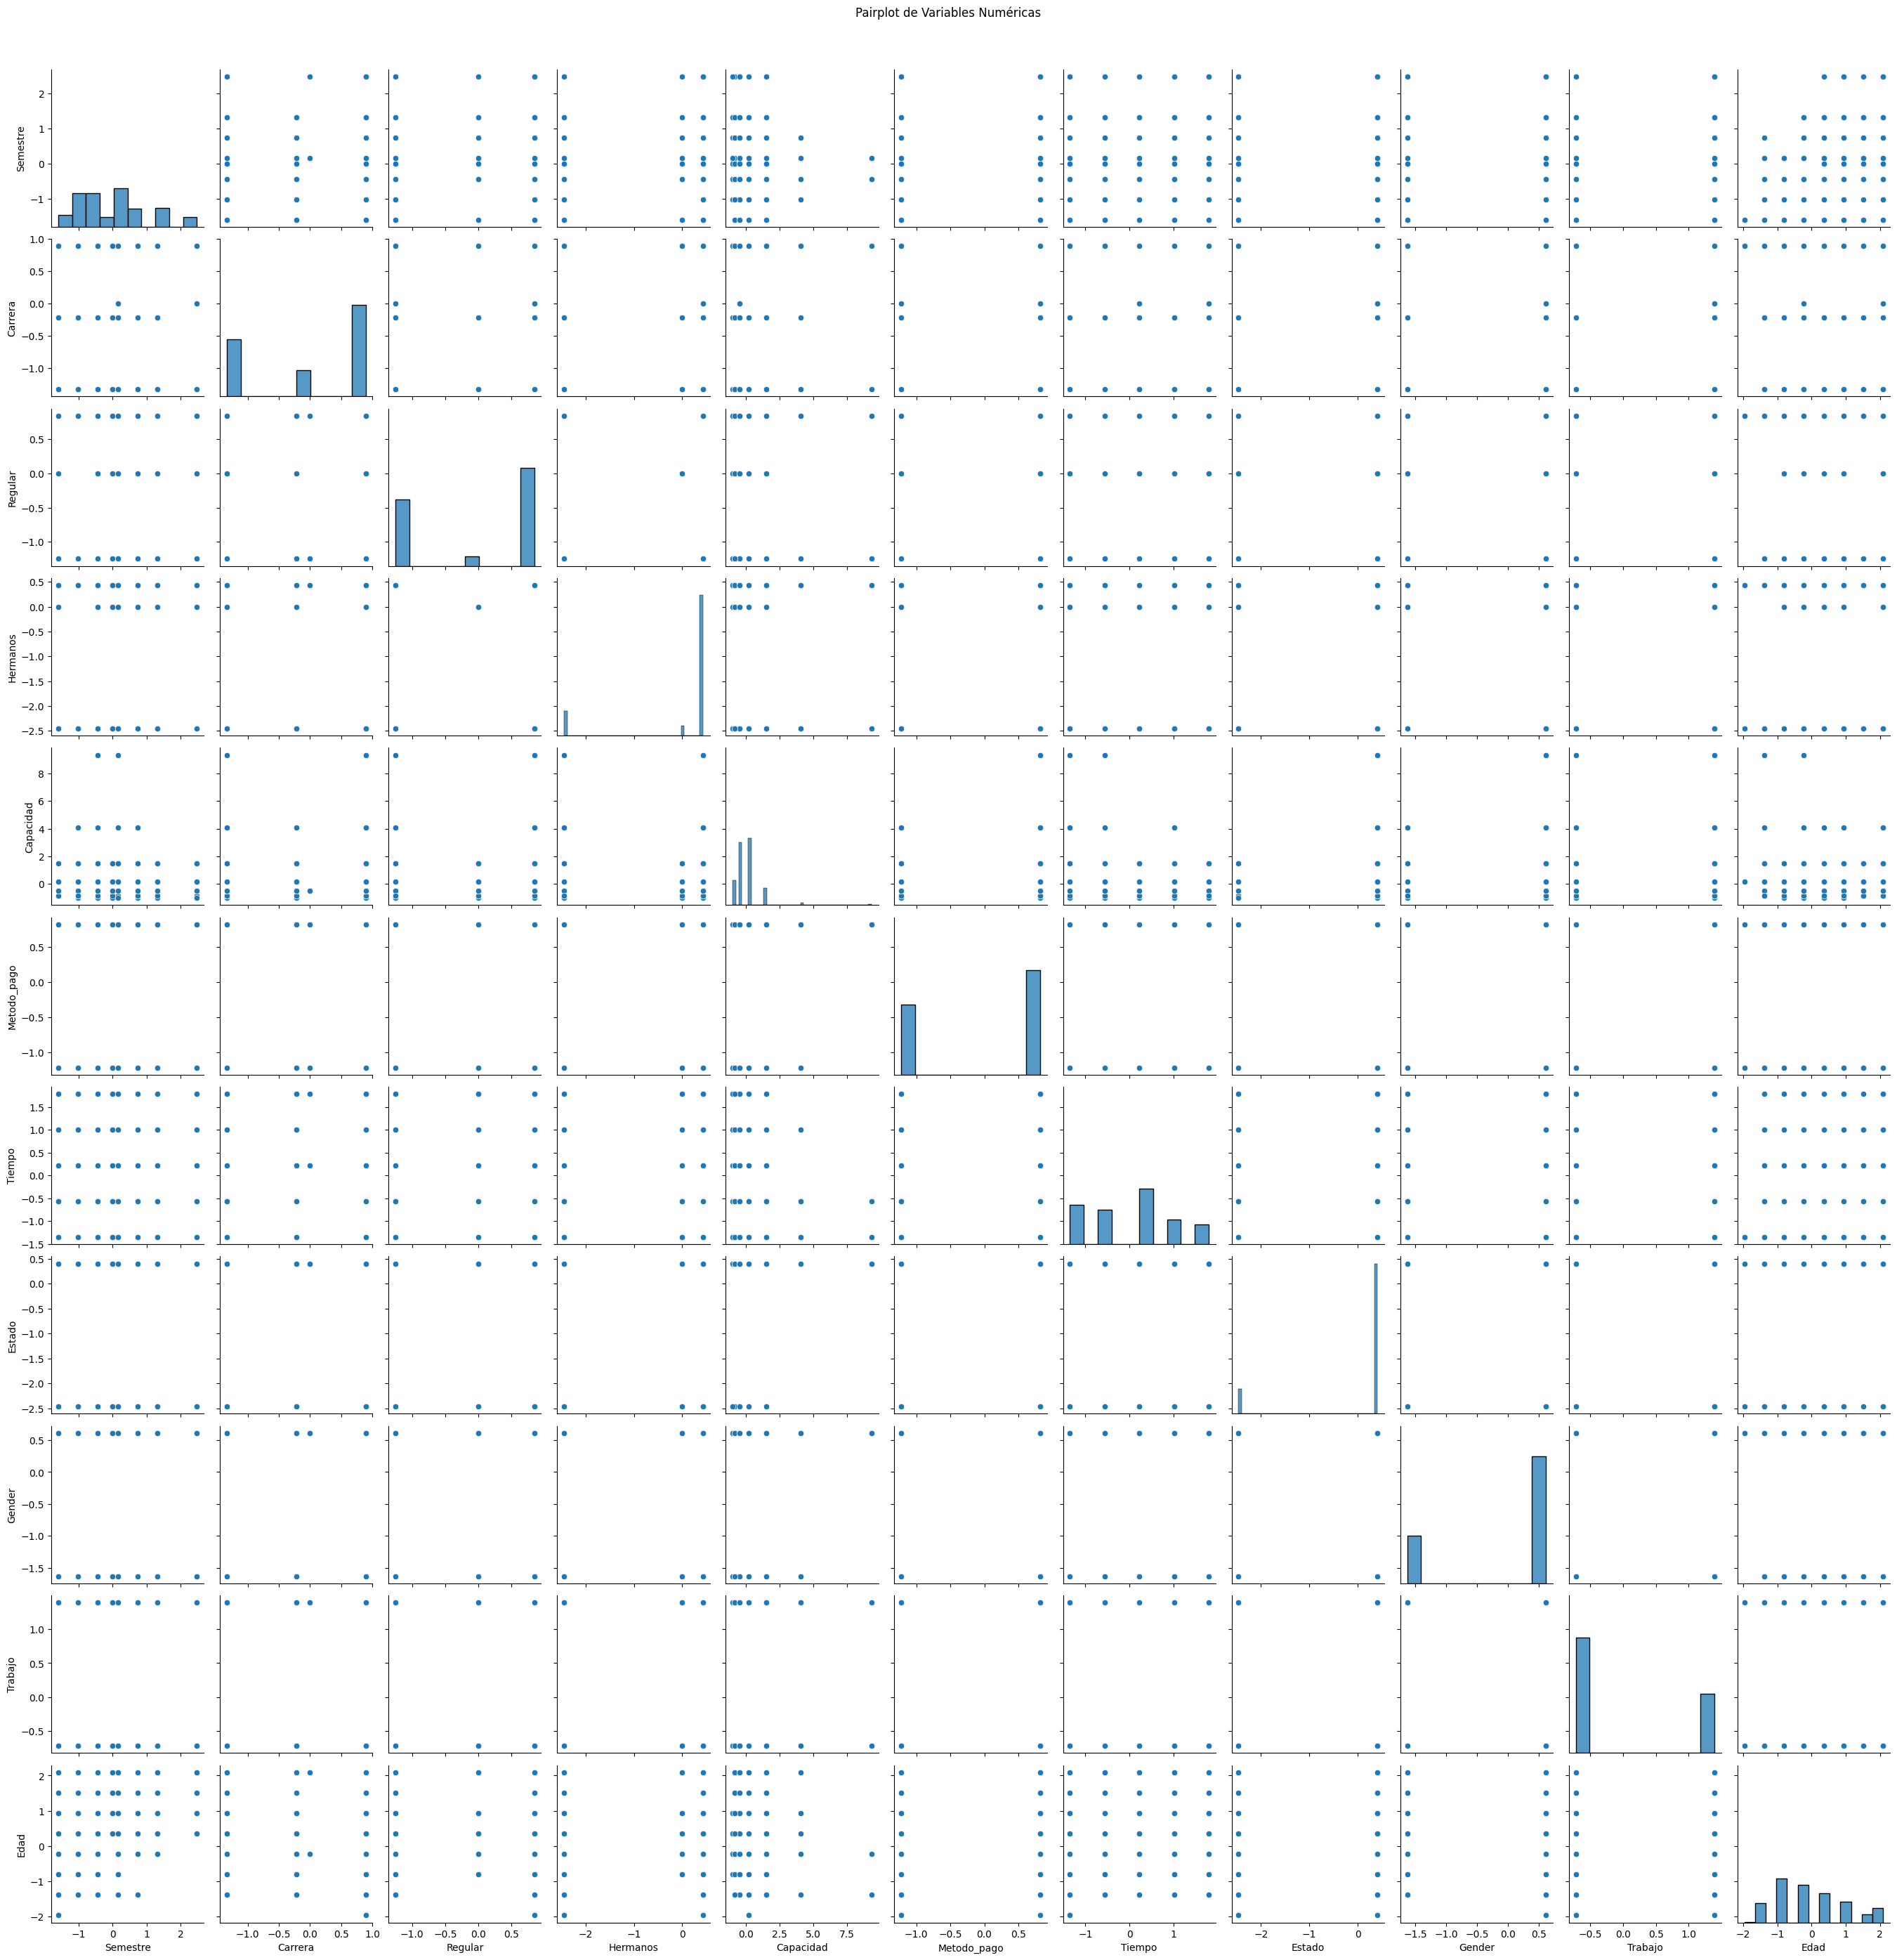

In [ ]:
sns.pairplot(df_estandarizado)
plt.suptitle('Pairplot de Variables Numéricas', y=1.02)
plt.show()


Variables disponibles para pairplot: ['Semestre', 'Edad', 'Capacidad', 'Tiempo', 'Regular', 'Hermanos', 'Metodo_pago', 'Estado', 'Trabajo']

📊 Generando pairplot...


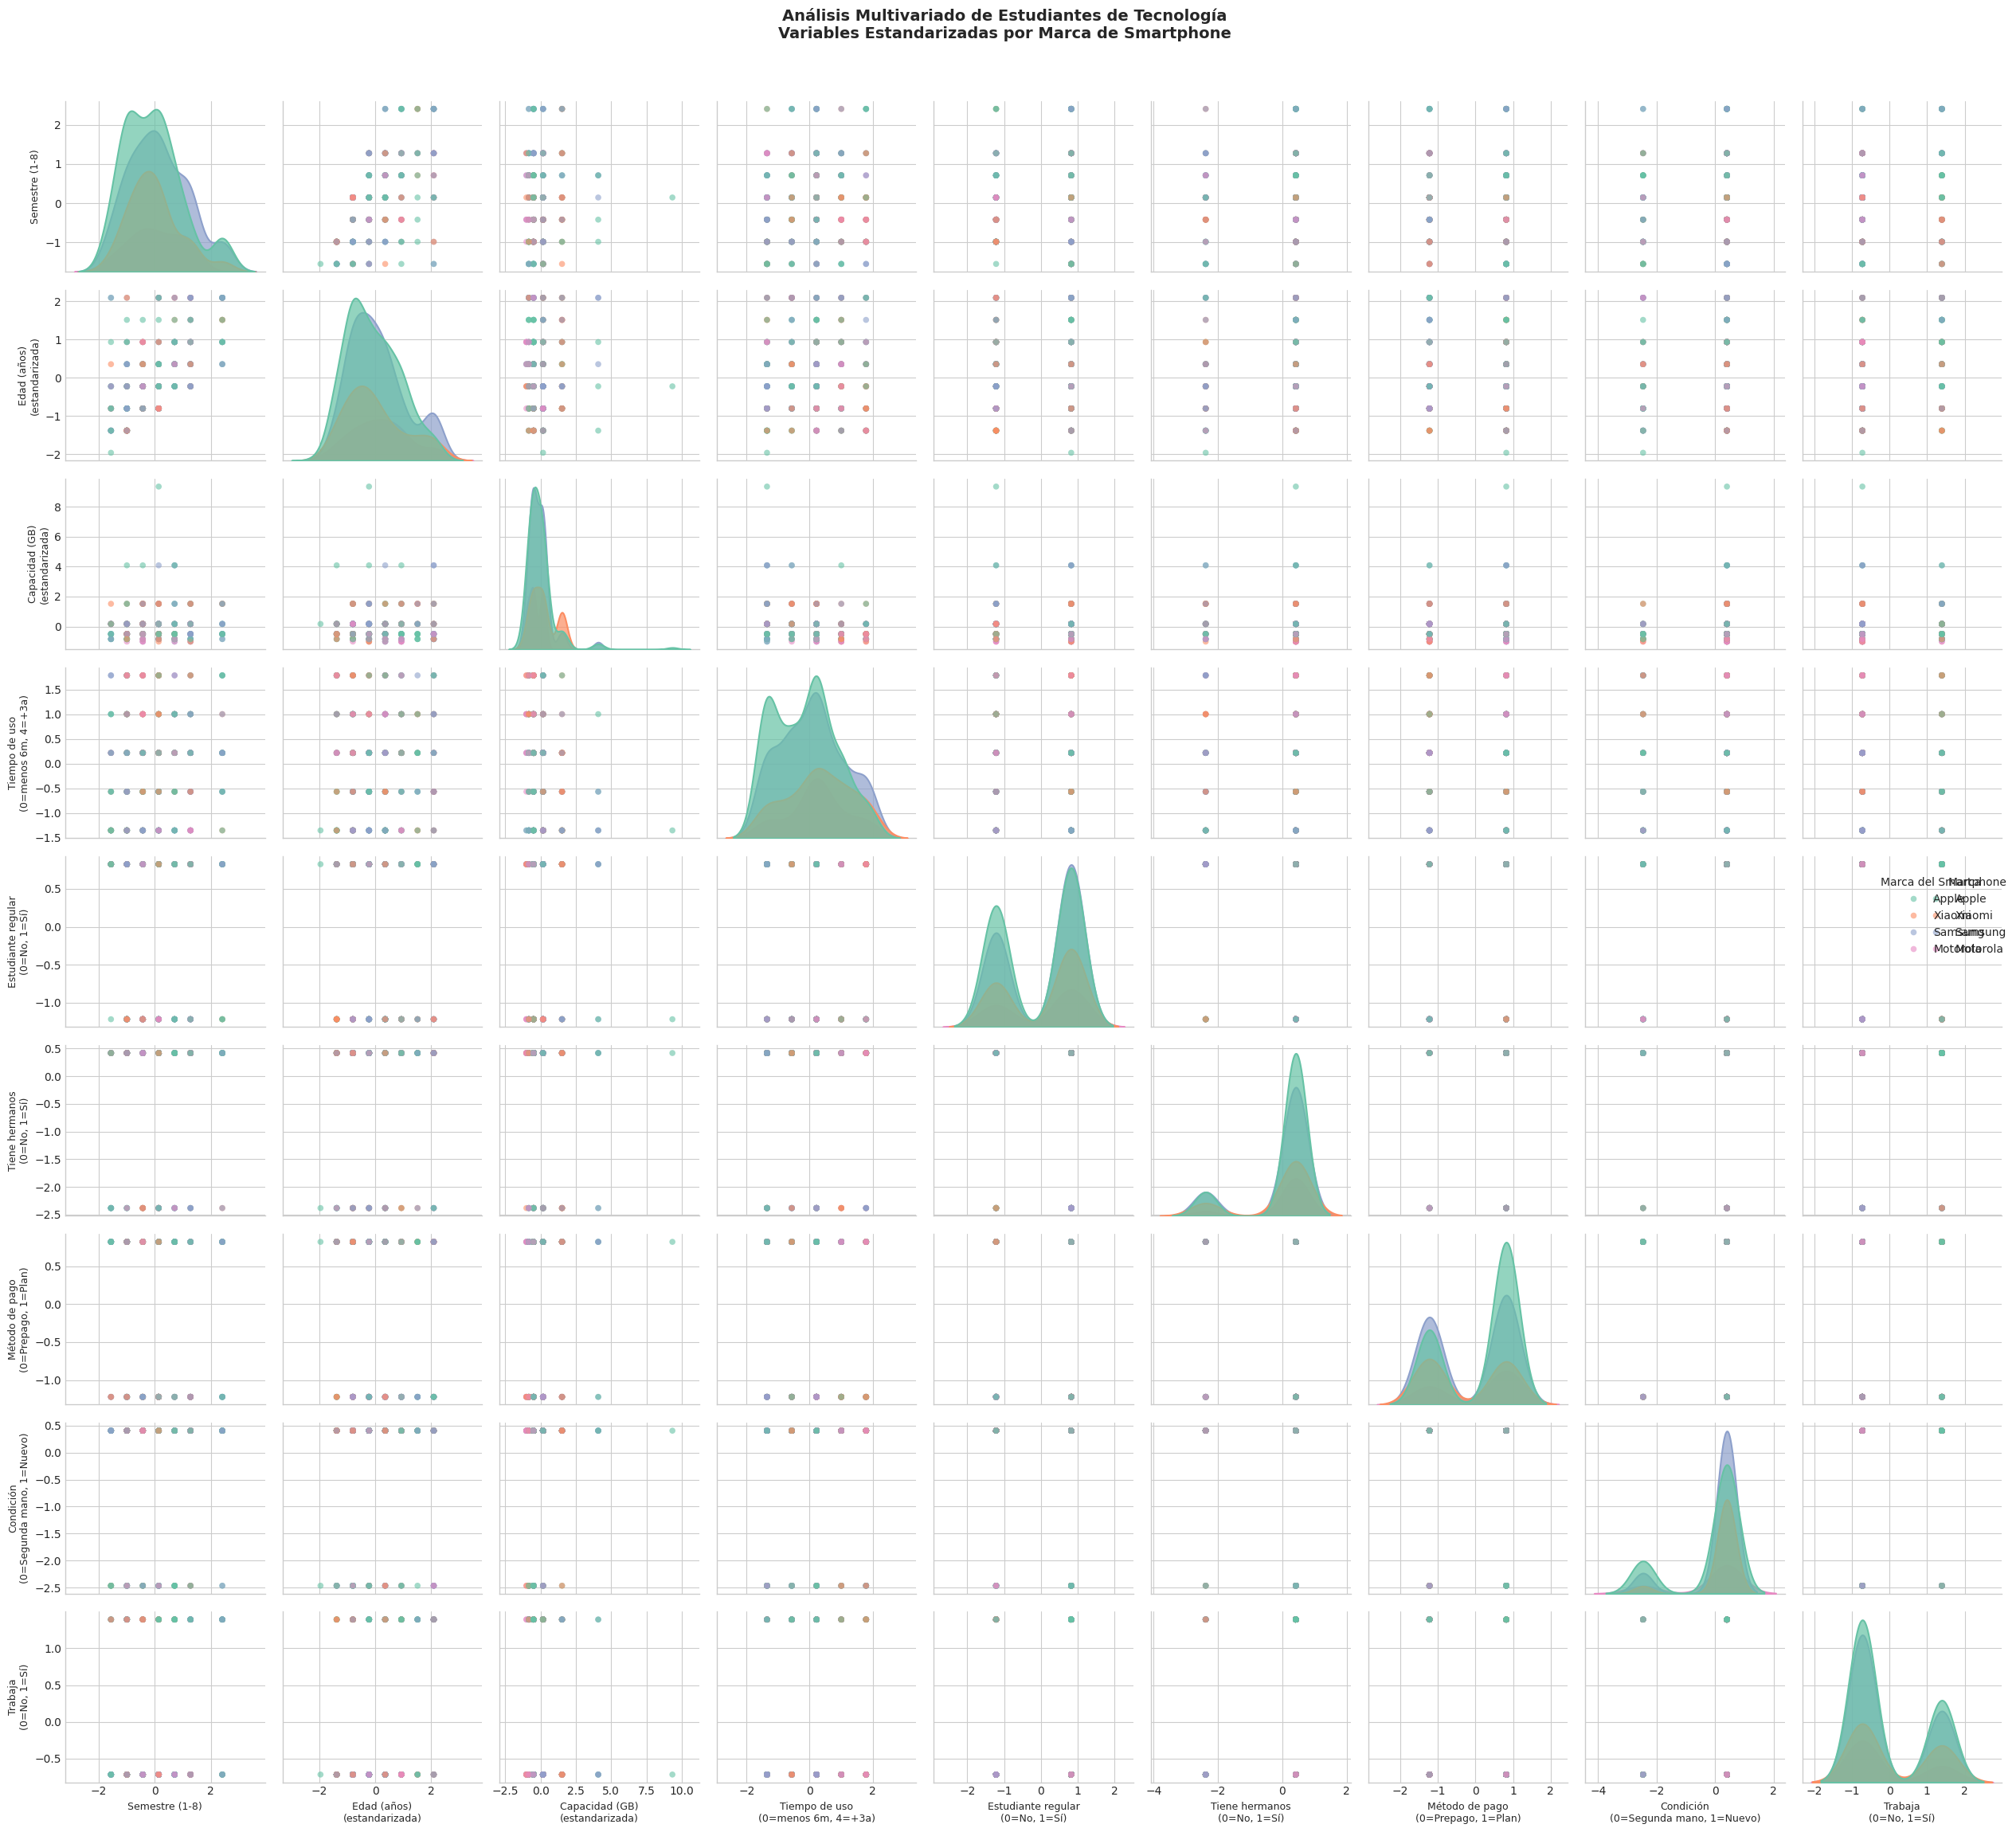

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Cargar tus datos procesados
data = pd.read_csv("data_sin_errores.csv")

# Seleccionar variables numéricas para pairplot
# (usando las que ya tienes transformadas)
variables_para_pairplot = [
    'Semestre',      # 1-8
    'Edad',          # 17-24
    'Capacidad',     # 32, 64, 128, 256, 512 GB
    'Tiempo',        # 0-4 (categorizado)
    'Regular',       # 0-1
    'Hermanos',      # 0-1
    'Metodo_pago',   # 0-1
    'Estado',        # 0-1
    'Trabajo'        # 0-1
]

# Filtrar solo las columnas que existen
variables_disponibles = [v for v in variables_para_pairplot if v in data.columns]
print(f"\nVariables disponibles para pairplot: {variables_disponibles}")

# Crear DataFrame con variables seleccionadas
df_pairplot = data[variables_disponibles].copy()

# Estandarizar estas variables para mejor visualización
scaler = StandardScaler()
df_pairplot_std = pd.DataFrame(
    scaler.fit_transform(df_pairplot),
    columns=df_pairplot.columns,
    index=df_pairplot.index
)

# Agregar la variable categórica 'Marca' para colorear (solo marcas principales)
marcas_top = data['Marca'].value_counts().head(4).index.tolist()
df_pairplot_std['Marca'] = data['Marca']
df_pairplot_std = df_pairplot_std[df_pairplot_std['Marca'].isin(marcas_top)]

# Crear pairplot con colores por marca
print("\n📊 Generando pairplot...")

# Configurar estilo
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# Crear pairplot personalizado
g = sns.pairplot(
    df_pairplot_std,
    vars=variables_disponibles,
    hue='Marca',
    palette='Set2',
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 30, 'edgecolor': 'none'},
    diag_kws={'alpha': 0.7, 'linewidth': 1.5},
    height=2.5
)

# Personalizar etiquetas (nombres más descriptivos)
etiquetas_descriptivas = {
    'Semestre': 'Semestre (1-8)',
    'Edad': 'Edad (años)\n(estandarizada)',
    'Capacidad': 'Capacidad (GB)\n(estandarizada)',
    'Tiempo': 'Tiempo de uso\n(0=menos 6m, 4=+3a)',
    'Regular': 'Estudiante regular\n(0=No, 1=Sí)',
    'Hermanos': 'Tiene hermanos\n(0=No, 1=Sí)',
    'Metodo_pago': 'Método de pago\n(0=Prepago, 1=Plan)',
    'Estado': 'Condición\n(0=Segunda mano, 1=Nuevo)',
    'Trabajo': 'Trabaja\n(0=No, 1=Sí)'
}

# Aplicar etiquetas personalizadas
for ax in g.axes.flatten():
    if ax is not None:
        # Cambiar etiqueta X
        if ax.get_xlabel() in etiquetas_descriptivas:
            ax.set_xlabel(etiquetas_descriptivas[ax.get_xlabel()], fontsize=9)
        # Cambiar etiqueta Y
        if ax.get_ylabel() in etiquetas_descriptivas:
            ax.set_ylabel(etiquetas_descriptivas[ax.get_ylabel()], fontsize=9)

# Personalizar título y leyenda
g.fig.suptitle('Análisis Multivariado de Estudiantes de Tecnología\nVariables Estandarizadas por Marca de Smartphone', 
               y=1.02, fontsize=14, fontweight='bold')
g.add_legend(title='Marca del Smartphone', title_fontsize=11, fontsize=10)

plt.tight_layout()
plt.savefig('pairplot_estandarizado.png', dpi=300, bbox_inches='tight')
plt.show()

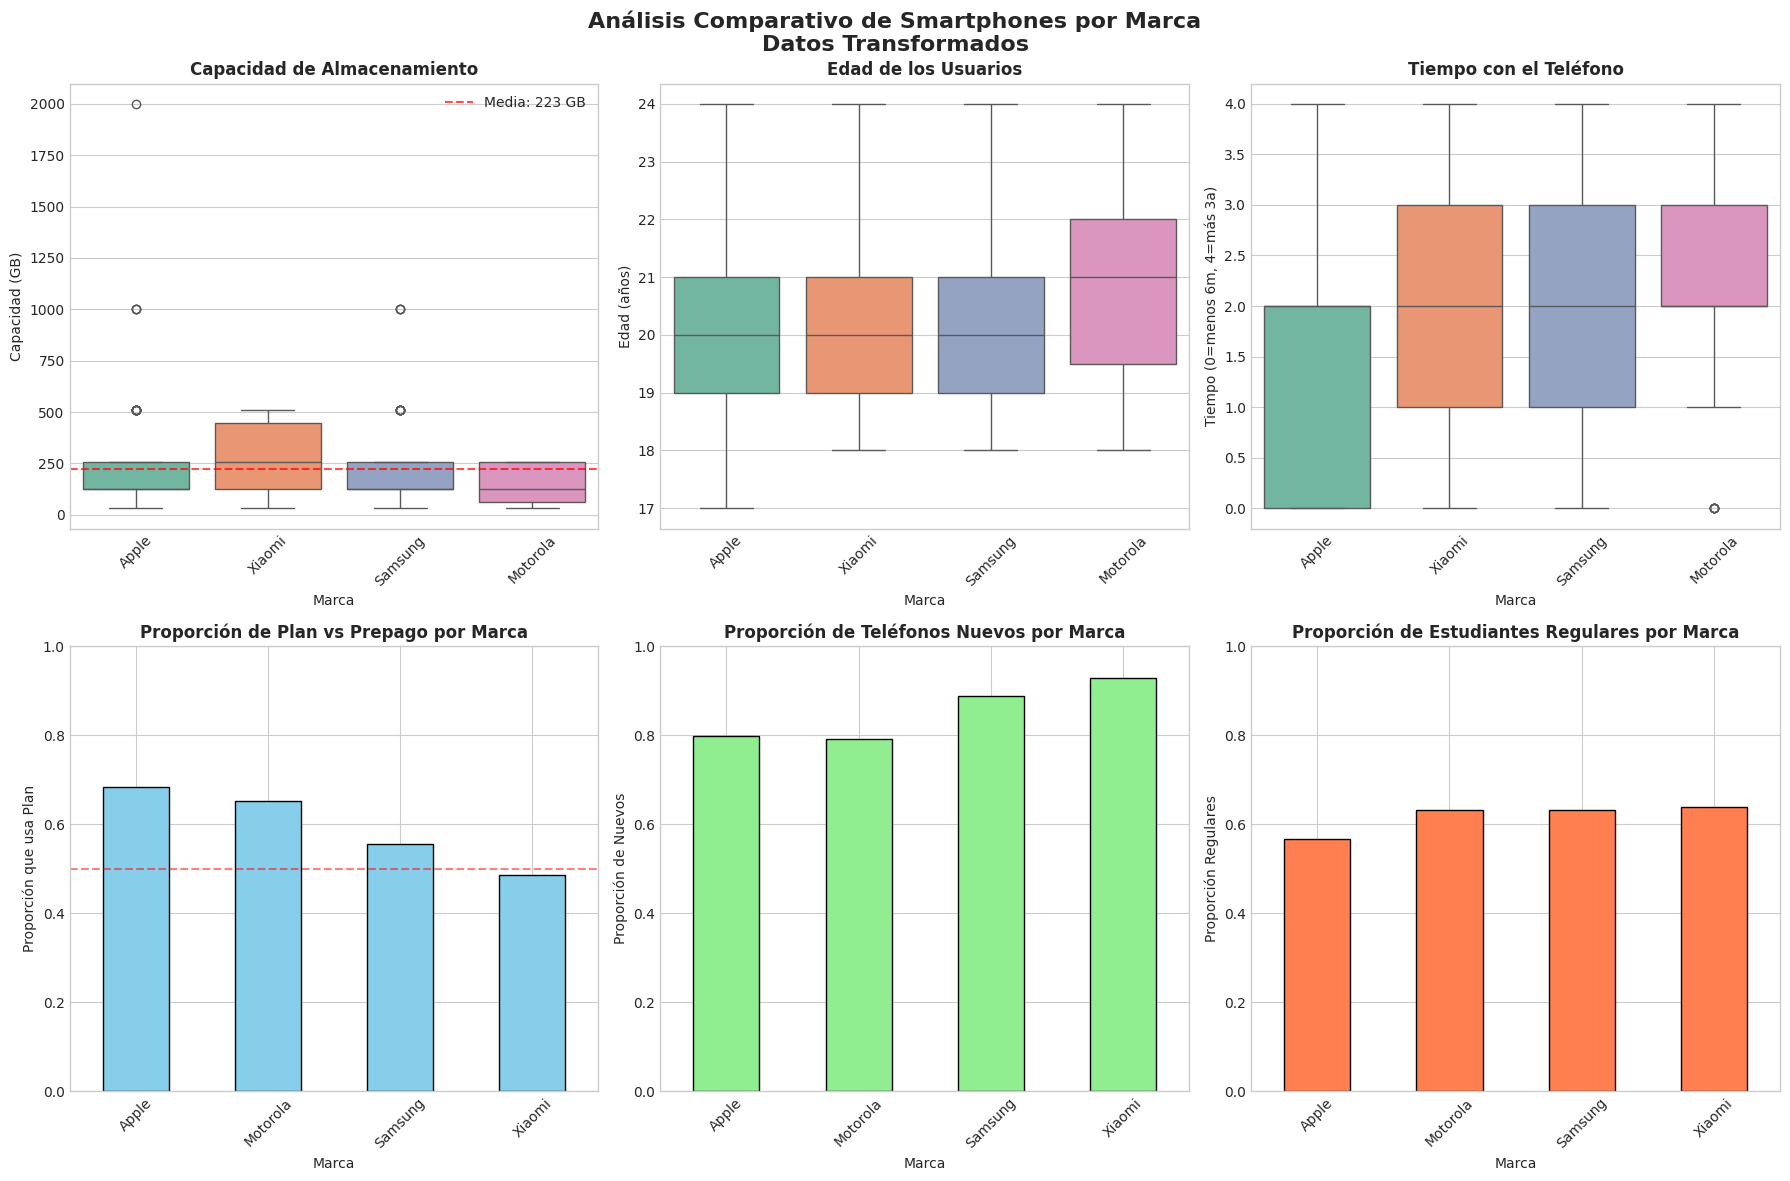

In [ ]:
# Configuración general
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Análisis Comparativo de Smartphones por Marca\nDatos Transformados', 
             fontsize=16, fontweight='bold')

# 1. Capacidad por Marca
sns.boxplot(ax=axes[0, 0], 
            data=data[data['Marca'].isin(marcas_top)],
            x='Marca', y='Capacidad', 
            palette='Set2')
axes[0, 0].set_title('Capacidad de Almacenamiento', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Marca', fontsize=10)
axes[0, 0].set_ylabel('Capacidad (GB)', fontsize=10)
axes[0, 0].tick_params(axis='x', rotation=45)

# Agregar línea de media general
media_capacidad = data['Capacidad'].mean()
axes[0, 0].axhline(media_capacidad, color='red', linestyle='--', alpha=0.7, label=f'Media: {media_capacidad:.0f} GB')
axes[0, 0].legend()

# 2. Edad por Marca
sns.boxplot(ax=axes[0, 1],
            data=data[data['Marca'].isin(marcas_top)],
            x='Marca', y='Edad', 
            palette='Set2')
axes[0, 1].set_title('Edad de los Usuarios', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Marca', fontsize=10)
axes[0, 1].set_ylabel('Edad (años)', fontsize=10)
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Tiempo de Uso por Marca
sns.boxplot(ax=axes[0, 2],
            data=data[data['Marca'].isin(marcas_top)],
            x='Marca', y='Tiempo', 
            palette='Set2')
axes[0, 2].set_title('Tiempo con el Teléfono', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Marca', fontsize=10)
axes[0, 2].set_ylabel('Tiempo (0=menos 6m, 4=más 3a)', fontsize=10)
axes[0, 2].tick_params(axis='x', rotation=45)

# 4. Método de Pago por Marca (gráfico de barras)
pago_por_marca = data[data['Marca'].isin(marcas_top)].groupby('Marca')['Metodo_pago'].mean()
marcas_order = pago_por_marca.index.tolist()
pago_por_marca.plot(ax=axes[1, 0], kind='bar', color='skyblue', edgecolor='black')
axes[1, 0].set_title('Proporción de Plan vs Prepago por Marca', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Marca', fontsize=10)
axes[1, 0].set_ylabel('Proporción que usa Plan', fontsize=10)
axes[1, 0].set_ylim(0, 1)
axes[1, 0].axhline(0.5, color='red', linestyle='--', alpha=0.5)
axes[1, 0].tick_params(axis='x', rotation=45)

# 5. Estado (Nuevo vs Segunda mano) por Marca
estado_por_marca = data[data['Marca'].isin(marcas_top)].groupby('Marca')['Estado'].mean()
estado_por_marca.plot(ax=axes[1, 1], kind='bar', color='lightgreen', edgecolor='black')
axes[1, 1].set_title('Proporción de Teléfonos Nuevos por Marca', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Marca', fontsize=10)
axes[1, 1].set_ylabel('Proporción de Nuevos', fontsize=10)
axes[1, 1].set_ylim(0, 1)
axes[1, 1].tick_params(axis='x', rotation=45)

# 6. Regularidad académica por Marca
regular_por_marca = data[data['Marca'].isin(marcas_top)].groupby('Marca')['Regular'].mean()
regular_por_marca.plot(ax=axes[1, 2], kind='bar', color='coral', edgecolor='black')
axes[1, 2].set_title('Proporción de Estudiantes Regulares por Marca', fontsize=12, fontweight='bold')
axes[1, 2].set_xlabel('Marca', fontsize=10)
axes[1, 2].set_ylabel('Proporción Regulares', fontsize=10)
axes[1, 2].set_ylim(0, 1)
axes[1, 2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('boxplots_por_marca.png', dpi=300, bbox_inches='tight')
plt.show()

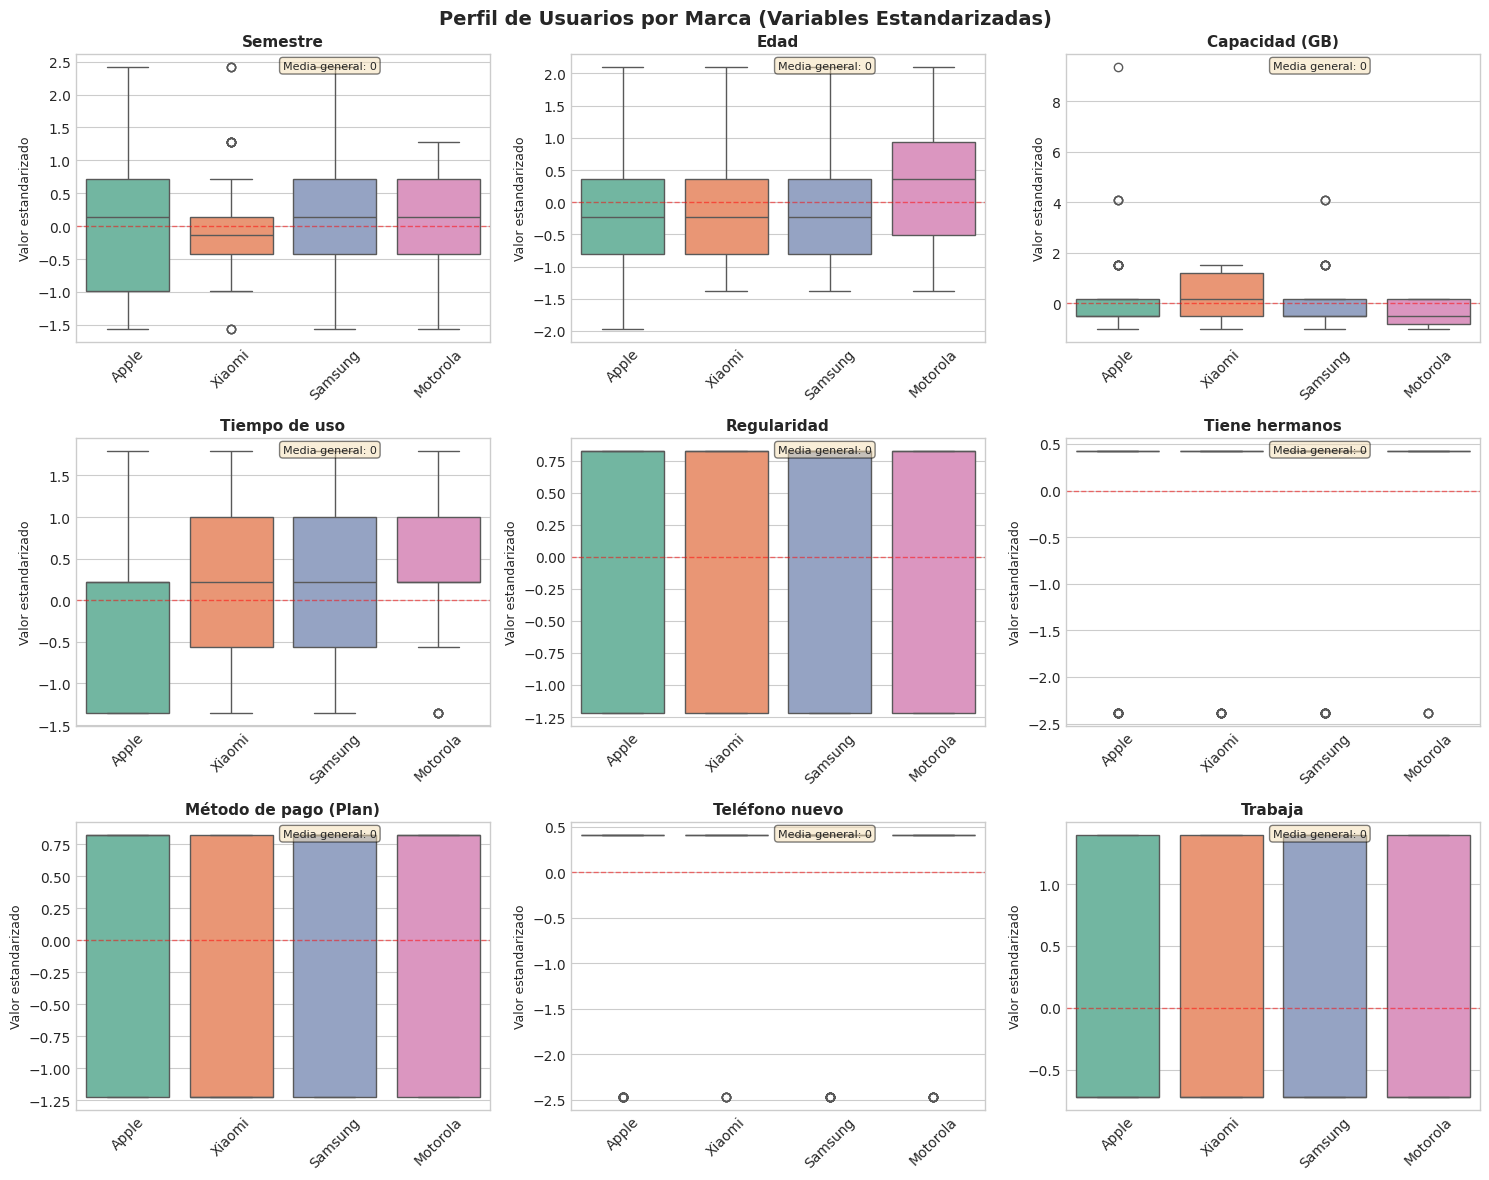

In [ ]:
# Estandarizar variables numéricas para comparación
from sklearn.preprocessing import StandardScaler

# Seleccionar variables numéricas
variables_num = ['Semestre', 'Edad', 'Capacidad', 'Tiempo', 'Regular', 'Hermanos', 'Metodo_pago', 'Estado', 'Trabajo']
df_num = data[variables_num].copy()

# Estandarizar
scaler = StandardScaler()
df_num_std = pd.DataFrame(
    scaler.fit_transform(df_num),
    columns=variables_num,
    index=df_num.index
)

# Agregar columna de marca
df_num_std['Marca'] = data['Marca'].values

# Filtrar marcas principales
df_plot = df_num_std[df_num_std['Marca'].isin(marcas_top)]

# Crear boxplots de todas las variables estandarizadas por marca
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Perfil de Usuarios por Marca (Variables Estandarizadas)', 
             fontsize=14, fontweight='bold')

variables_titles = {
    'Semestre': 'Semestre',
    'Edad': 'Edad',
    'Capacidad': 'Capacidad (GB)',
    'Tiempo': 'Tiempo de uso',
    'Regular': 'Regularidad',
    'Hermanos': 'Tiene hermanos',
    'Metodo_pago': 'Método de pago (Plan)',
    'Estado': 'Teléfono nuevo',
    'Trabajo': 'Trabaja'
}

for idx, var in enumerate(variables_num):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    sns.boxplot(ax=ax,
                data=df_plot,
                x='Marca', y=var,
                palette='Set2')
    
    ax.set_title(variables_titles[var], fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Valor estandarizado', fontsize=9)
    ax.axhline(0, color='red', linestyle='--', alpha=0.5, linewidth=1)
    ax.tick_params(axis='x', rotation=45)
    
    # Agregar línea de media cero
    ax.text(0.5, 0.95, f'Media general: 0', 
            transform=ax.transAxes, fontsize=8, 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('boxplots_estandarizados.png', dpi=300, bbox_inches='tight')
plt.show()

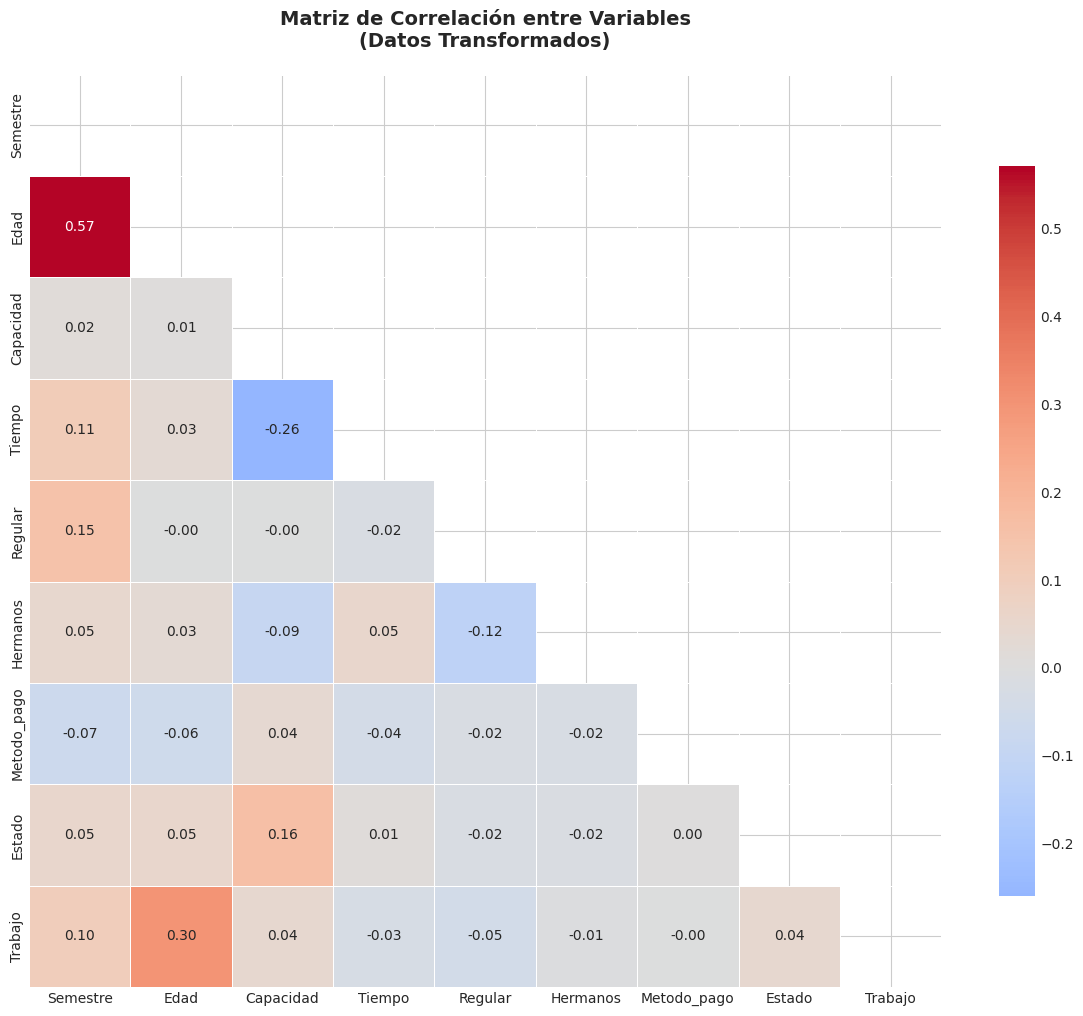


📊 Correlaciones más relevantes:

Top 10 correlaciones positivas:
  Edad ↔ Semestre: 0.572
  Semestre ↔ Edad: 0.572
  Edad ↔ Trabajo: 0.300
  Trabajo ↔ Edad: 0.300
  Capacidad ↔ Estado: 0.163
  Estado ↔ Capacidad: 0.163
  Regular ↔ Semestre: 0.150
  Semestre ↔ Regular: 0.150
  Tiempo ↔ Semestre: 0.110
  Semestre ↔ Tiempo: 0.110

Top 10 correlaciones negativas:
  Metodo_pago ↔ Edad: -0.061
  Edad ↔ Metodo_pago: -0.061
  Semestre ↔ Metodo_pago: -0.066
  Metodo_pago ↔ Semestre: -0.066
  Capacidad ↔ Hermanos: -0.088
  Hermanos ↔ Capacidad: -0.088
  Regular ↔ Hermanos: -0.122
  Hermanos ↔ Regular: -0.122
  Capacidad ↔ Tiempo: -0.259
  Tiempo ↔ Capacidad: -0.259


In [ ]:
# Matriz de correlación con tus datos
plt.figure(figsize=(12, 10))

# Calcular correlación
corr_matrix = data[variables_num].corr()

# Crear heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, 
            mask=mask,
            annot=True, 
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})

plt.title('Matriz de Correlación entre Variables\n(Datos Transformados)', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('matriz_correlacion.png', dpi=300, bbox_inches='tight')
plt.show()

# Interpretación de correlaciones interesantes
print("\n📊 Correlaciones más relevantes:")
corr_pairs = corr_matrix.unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1]  # Eliminar autocorrelaciones

print("\nTop 10 correlaciones positivas:")
for idx, (var1, var2), corr in zip(range(10), corr_pairs.head(10).index, corr_pairs.head(10).values):
    print(f"  {var1} ↔ {var2}: {corr:.3f}")

print("\nTop 10 correlaciones negativas:")
for idx, (var1, var2), corr in zip(range(10), corr_pairs.tail(10).index, corr_pairs.tail(10).values):
    print(f"  {var1} ↔ {var2}: {corr:.3f}")

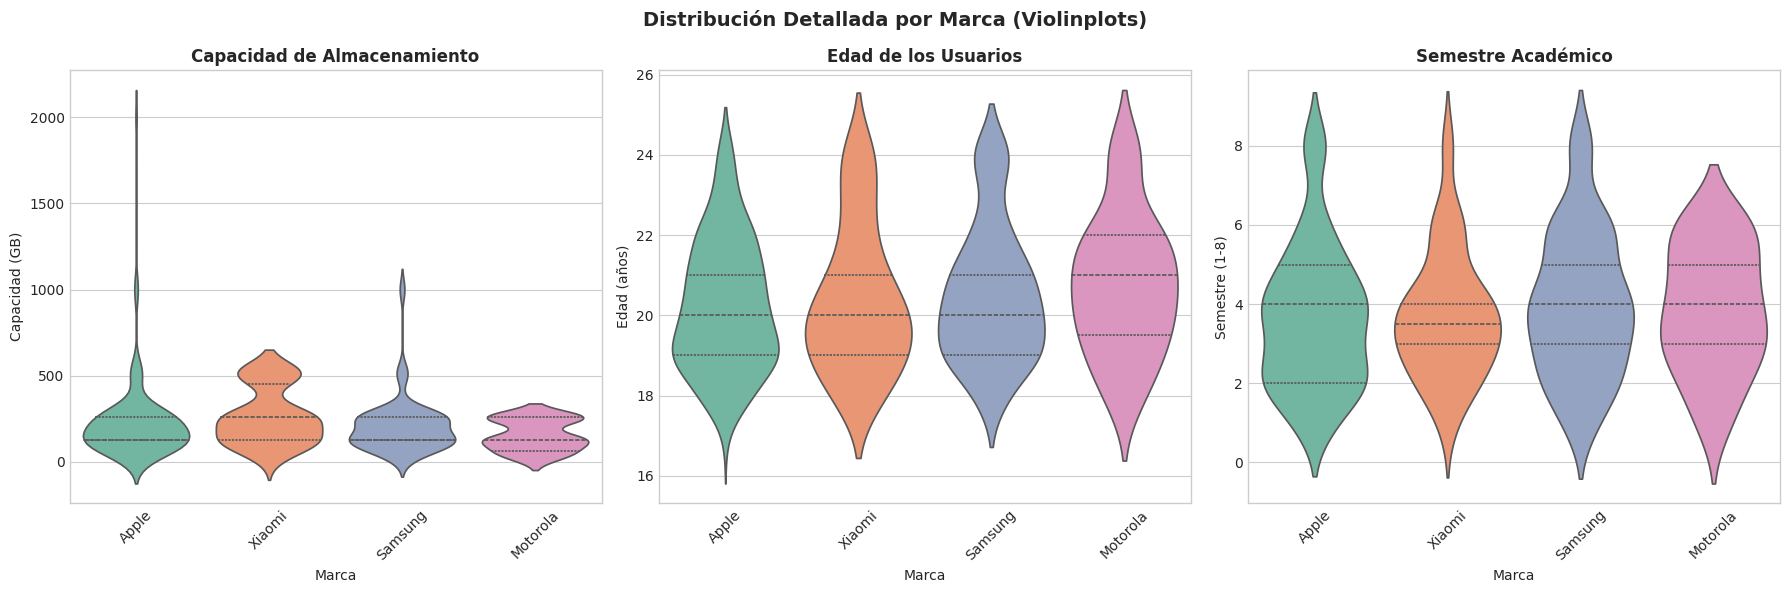

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Distribución Detallada por Marca (Violinplots)', 
             fontsize=14, fontweight='bold')

# 1. Capacidad por Marca
sns.violinplot(ax=axes[0],
               data=data[data['Marca'].isin(marcas_top)],
               x='Marca', y='Capacidad', 
               palette='Set2',
               inner='quartile')
axes[0].set_title('Capacidad de Almacenamiento', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Marca', fontsize=10)
axes[0].set_ylabel('Capacidad (GB)', fontsize=10)
axes[0].tick_params(axis='x', rotation=45)

# 2. Edad por Marca
sns.violinplot(ax=axes[1],
               data=data[data['Marca'].isin(marcas_top)],
               x='Marca', y='Edad', 
               palette='Set2',
               inner='quartile')
axes[1].set_title('Edad de los Usuarios', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Marca', fontsize=10)
axes[1].set_ylabel('Edad (años)', fontsize=10)
axes[1].tick_params(axis='x', rotation=45)

# 3. Semestre por Marca
sns.violinplot(ax=axes[2],
               data=data[data['Marca'].isin(marcas_top)],
               x='Marca', y='Semestre', 
               palette='Set2',
               inner='quartile')
axes[2].set_title('Semestre Académico', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Marca', fontsize=10)
axes[2].set_ylabel('Semestre (1-8)', fontsize=10)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('violinplots_por_marca.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Cargar tus datos procesados
data = pd.read_csv("data_sin_errores.csv")

print("📊 Datos cargados:")
print(f"Shape: {data.shape}")
print(f"\nColumnas numéricas disponibles:")
columnas_numericas = data.select_dtypes(include=[np.number]).columns.tolist()
print(columnas_numericas)

# Definir funciones para calcular número de bins

def bins_sturges(data):
    """
    Regla de Sturges: k = 1 + log2(n)
    Funciona mejor para distribuciones normales y tamaños de muestra pequeños
    """
    n = len(data.dropna())
    k = int(np.ceil(1 + np.log2(n)))
    return k

def bins_raiz(data):
    """
    Regla de la raíz cuadrada: k = √n
    Regla simple y comúnmente utilizada
    """
    n = len(data.dropna())
    k = int(np.ceil(np.sqrt(n)))
    return k

def bins_freedman_diaconis(data):
    """
    Regla de Freedman-Diaconis: k = (max - min) / (2 * IQR * n^(-1/3))
    Más robusta para datos con outliers y distribuciones no normales
    """
    data_clean = data.dropna()
    n = len(data_clean)
    
    if n == 0:
        return 10  # Valor por defecto
    
    q75, q25 = np.percentile(data_clean, [75, 25])
    iqr = q75 - q25
    
    if iqr == 0:
        # Si IQR es cero, usar regla de Sturges como fallback
        return bins_sturges(data)
    
    bin_width = 2 * iqr / (n ** (1/3))
    
    if bin_width == 0:
        return bins_sturges(data)
    
    data_range = data_clean.max() - data_clean.min()
    k = int(np.ceil(data_range / bin_width))
    
    # Limitar número de bins para evitar valores extremos
    k = max(3, min(k, 50))
    
    return k

def calcular_bins_para_variable(data, variable):
    """
    Calcula los bins para una variable usando las tres reglas
    """
    data_clean = data[variable].dropna()
    n = len(data_clean)
    
    if n == 0:
        return None, None, None
    
    bins = {
        'Sturges': bins_sturges(data_clean),
        'Raíz': bins_raiz(data_clean),
        'Freedman-Diaconis': bins_freedman_diaconis(data_clean)
    }
    
    return bins, n

📊 Datos cargados:
Shape: (488, 17)

Columnas numéricas disponibles:
['Semestre', 'Carrera', 'Regular', 'Hermanos', 'Capacidad', 'Metodo_pago', 'Tiempo', 'Estado', 'Gender', 'Trabajo', 'Edad']



📊 Variables a analizar:
  • Semestre
  • Edad
  • Capacidad
  • Tiempo
  • Regular
  • Hermanos
  • Metodo_pago
  • Estado
  • Trabajo

📊 Procesando variable: Semestre
  • Número de datos: 461
  • Bins Sturges: 10
  • Bins Raíz: 22
  • Bins Freedman-Diaconis: 10


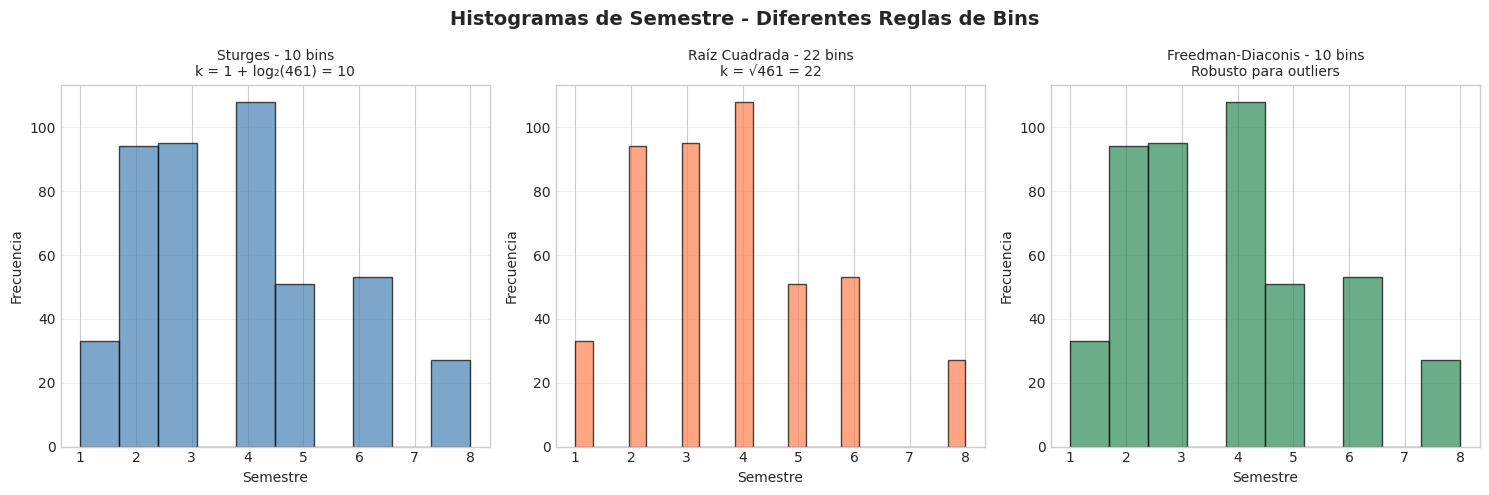


📊 Procesando variable: Edad
  • Número de datos: 488
  • Bins Sturges: 10
  • Bins Raíz: 23
  • Bins Freedman-Diaconis: 13


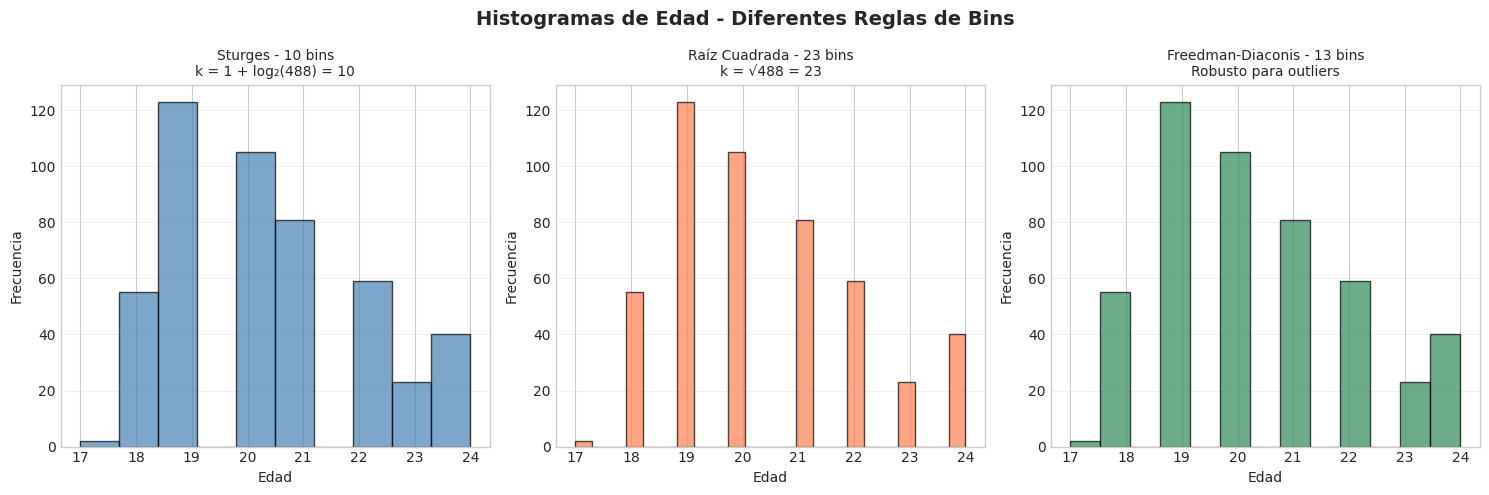


📊 Procesando variable: Capacidad
  • Número de datos: 488
  • Bins Sturges: 10
  • Bins Raíz: 23
  • Bins Freedman-Diaconis: 50


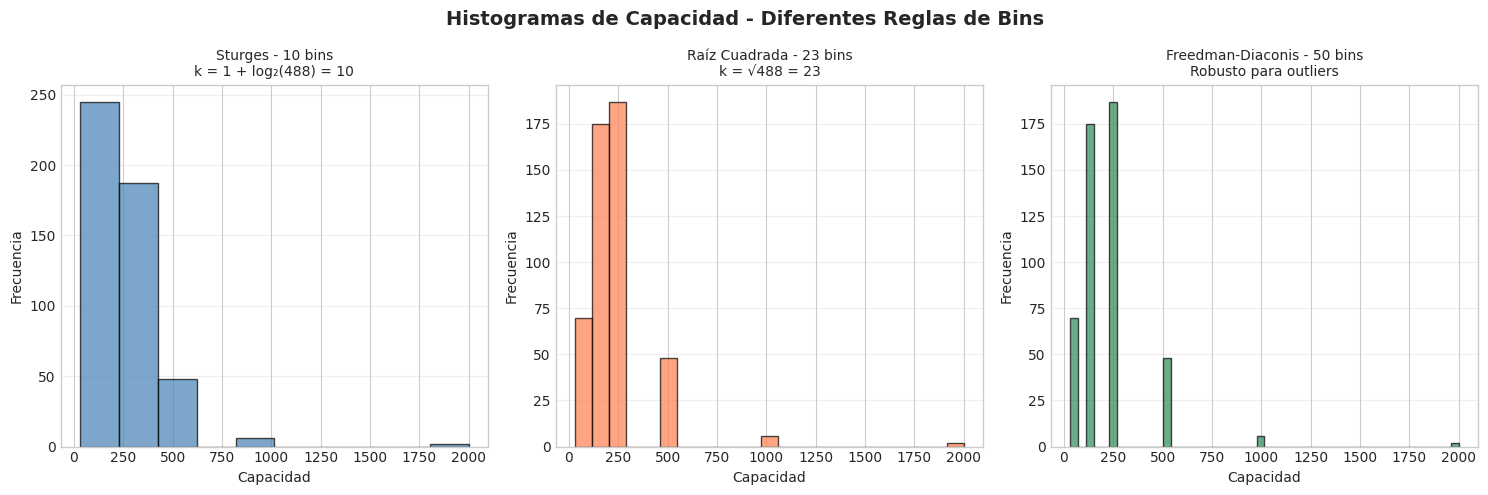


📊 Procesando variable: Tiempo
  • Número de datos: 488
  • Bins Sturges: 10
  • Bins Raíz: 23
  • Bins Freedman-Diaconis: 8


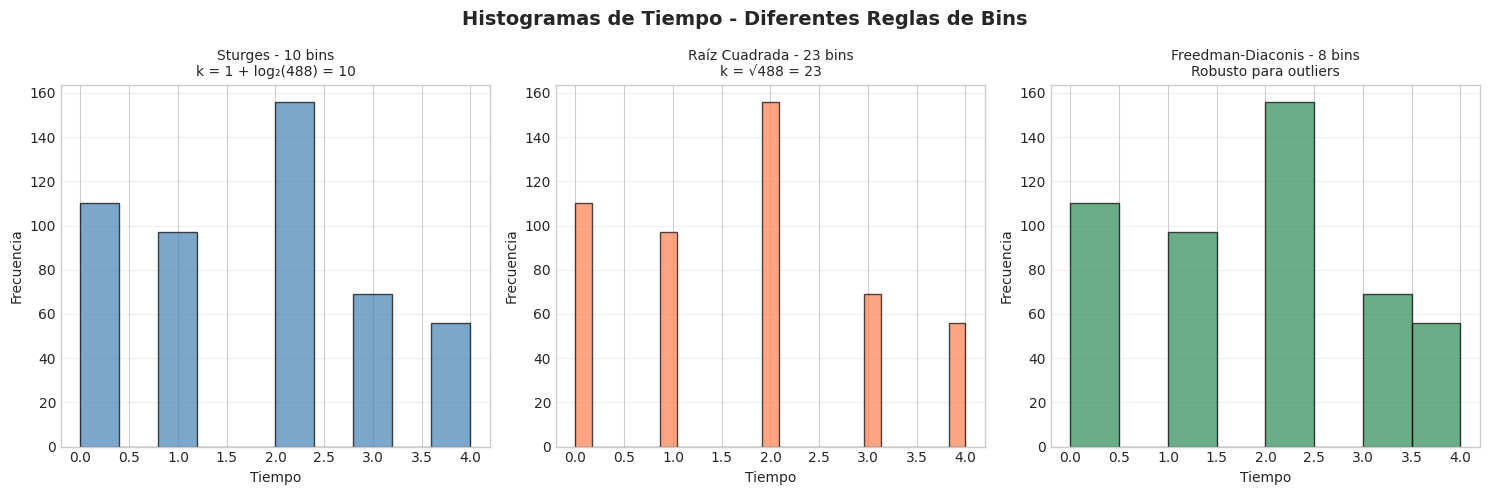


📊 Procesando variable: Regular
  • Número de datos: 461
  • Bins Sturges: 10
  • Bins Raíz: 22
  • Bins Freedman-Diaconis: 4


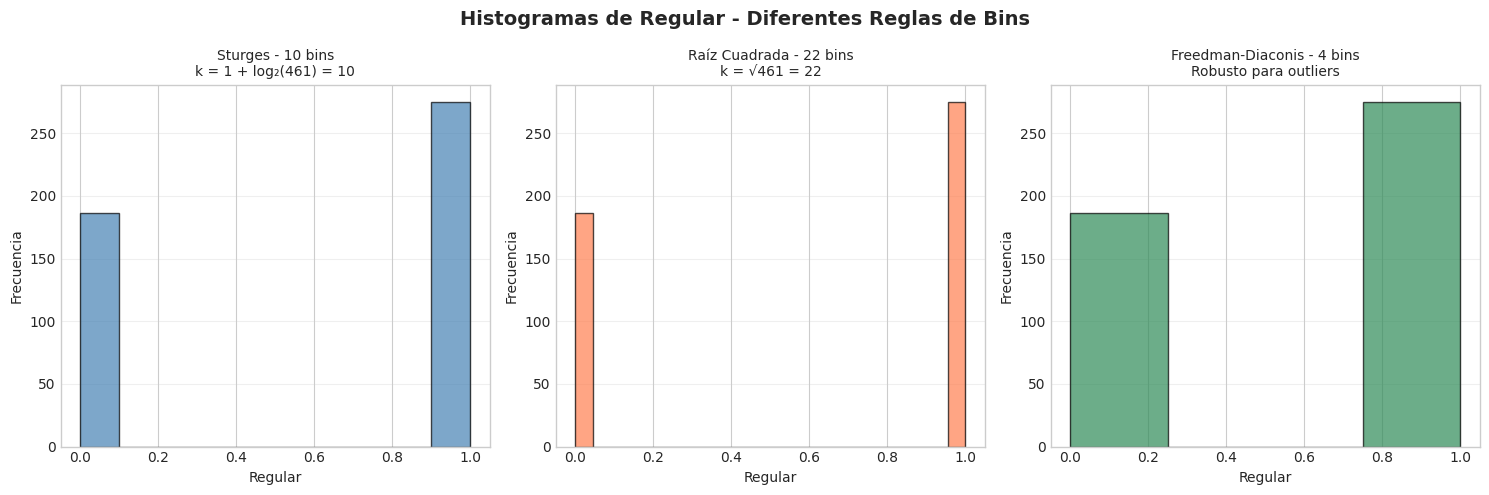


📊 Procesando variable: Hermanos
  • Número de datos: 461
  • Bins Sturges: 10
  • Bins Raíz: 22
  • Bins Freedman-Diaconis: 10


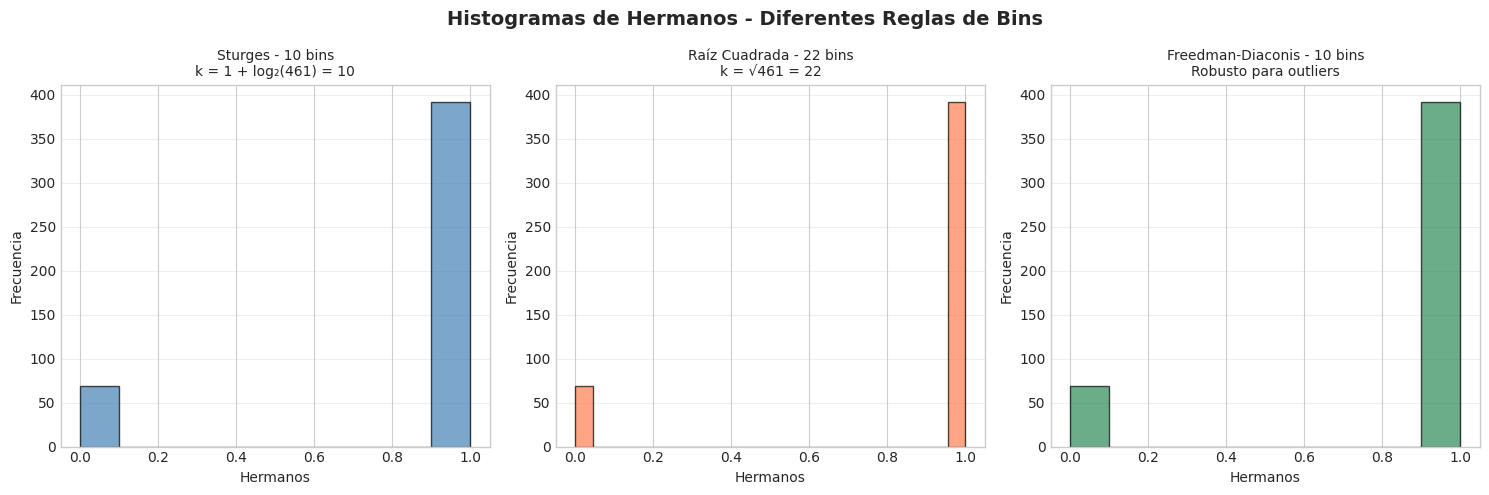


📊 Procesando variable: Metodo_pago
  • Número de datos: 488
  • Bins Sturges: 10
  • Bins Raíz: 23
  • Bins Freedman-Diaconis: 4


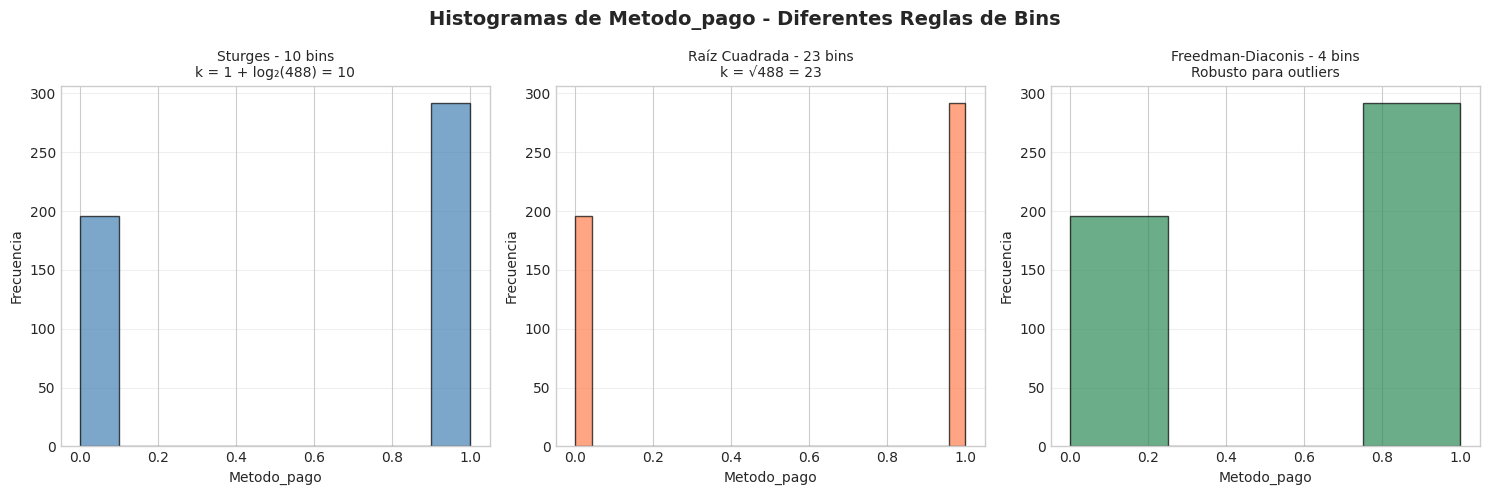


📊 Procesando variable: Estado
  • Número de datos: 488
  • Bins Sturges: 10
  • Bins Raíz: 23
  • Bins Freedman-Diaconis: 10


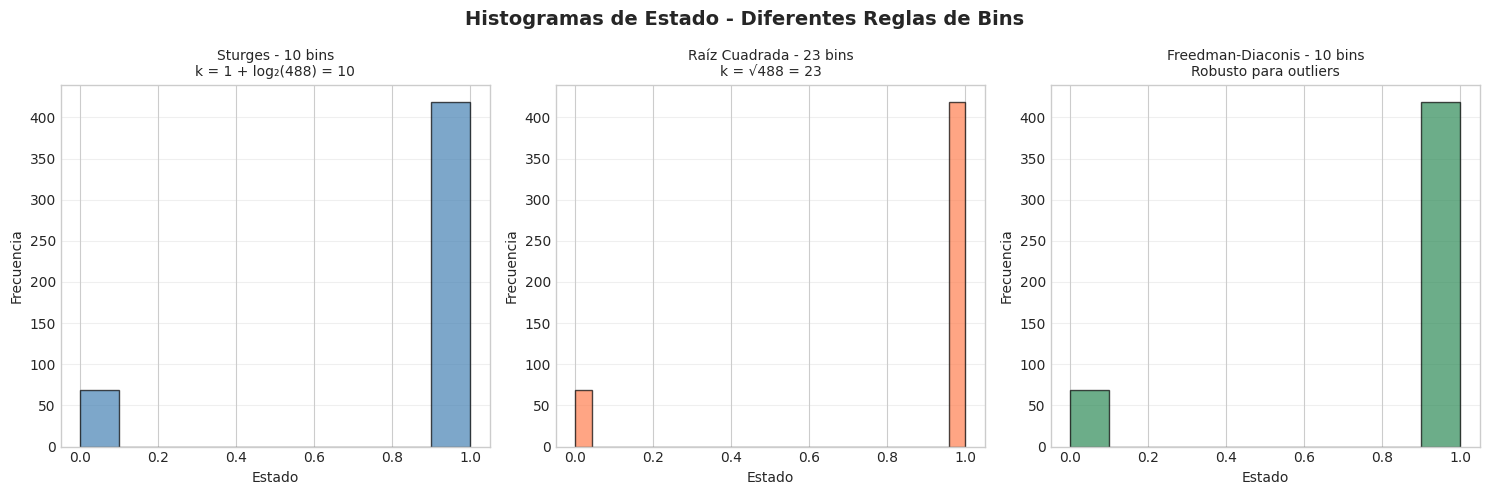


📊 Procesando variable: Trabajo
  • Número de datos: 488
  • Bins Sturges: 10
  • Bins Raíz: 23
  • Bins Freedman-Diaconis: 4


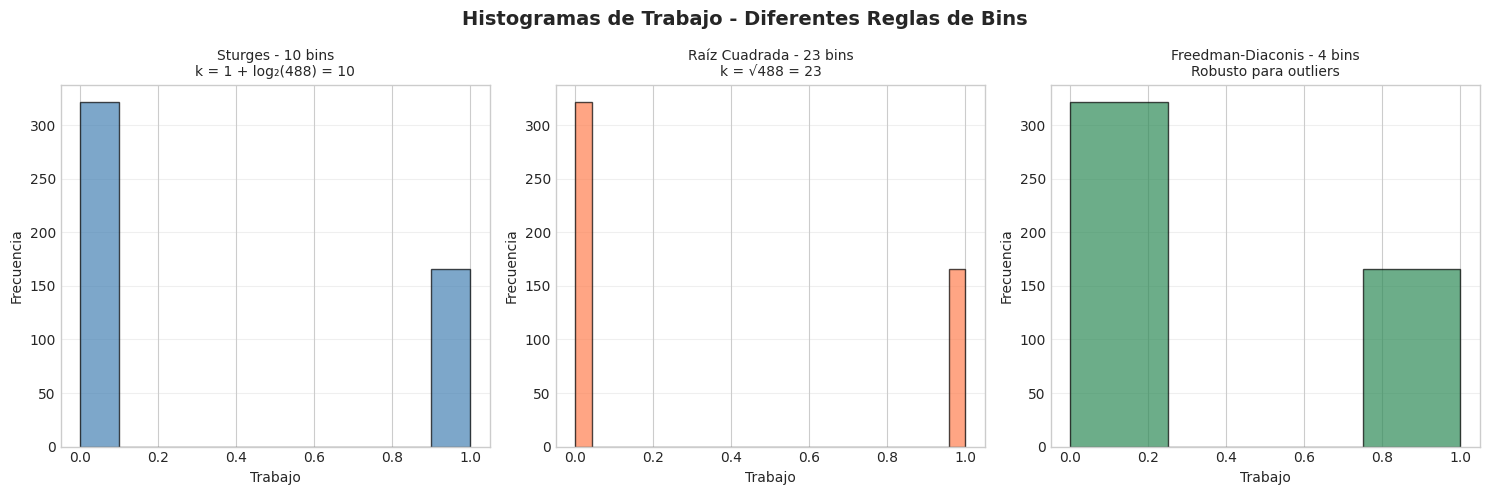

In [ ]:
# Seleccionar variables numéricas relevantes
variables_a_analizar = [
    'Semestre', 'Edad', 'Capacidad', 'Tiempo',
    'Regular', 'Hermanos', 'Metodo_pago', 'Estado', 'Trabajo'
]

# Filtrar solo las que existen
variables_a_analizar = [v for v in variables_a_analizar if v in data.columns]

print("\n📊 Variables a analizar:")
for var in variables_a_analizar:
    print(f"  • {var}")

# Configuración general
plt.style.use('seaborn-v0_8-whitegrid')
figuras = []

# Crear histogramas para cada variable
for variable in variables_a_analizar:
    print(f"\n📊 Procesando variable: {variable}")
    
    # Calcular bins
    bins_dict, n = calcular_bins_para_variable(data, variable)
    
    if bins_dict is None:
        print(f"  ⚠️ No hay datos válidos para {variable}")
        continue
    
    print(f"  • Número de datos: {n}")
    print(f"  • Bins Sturges: {bins_dict['Sturges']}")
    print(f"  • Bins Raíz: {bins_dict['Raíz']}")
    print(f"  • Bins Freedman-Diaconis: {bins_dict['Freedman-Diaconis']}")
    
    # Crear figura con 3 subplots
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'Histogramas de {variable} - Diferentes Reglas de Bins', 
                 fontsize=14, fontweight='bold')
    
    # Datos limpios
    data_clean = data[variable].dropna()
    
    # 1. Sturges
    axes[0].hist(data_clean, bins=bins_dict['Sturges'], 
                 edgecolor='black', alpha=0.7, color='steelblue')
    axes[0].set_title(f'Sturges - {bins_dict["Sturges"]} bins\nk = 1 + log₂({n}) = {bins_dict["Sturges"]}', 
                      fontsize=10)
    axes[0].set_xlabel(variable, fontsize=10)
    axes[0].set_ylabel('Frecuencia', fontsize=10)
    axes[0].grid(axis='y', alpha=0.3)
    
    # 2. Raíz
    axes[1].hist(data_clean, bins=bins_dict['Raíz'], 
                 edgecolor='black', alpha=0.7, color='coral')
    axes[1].set_title(f'Raíz Cuadrada - {bins_dict["Raíz"]} bins\nk = √{n} = {bins_dict["Raíz"]}', 
                      fontsize=10)
    axes[1].set_xlabel(variable, fontsize=10)
    axes[1].set_ylabel('Frecuencia', fontsize=10)
    axes[1].grid(axis='y', alpha=0.3)
    
    # 3. Freedman-Diaconis
    axes[2].hist(data_clean, bins=bins_dict['Freedman-Diaconis'], 
                 edgecolor='black', alpha=0.7, color='seagreen')
    axes[2].set_title(f'Freedman-Diaconis - {bins_dict["Freedman-Diaconis"]} bins\nRobusto para outliers', 
                      fontsize=10)
    axes[2].set_xlabel(variable, fontsize=10)
    axes[2].set_ylabel('Frecuencia', fontsize=10)
    axes[2].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'histograma_{variable}_comparacion.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    figuras.append(fig)

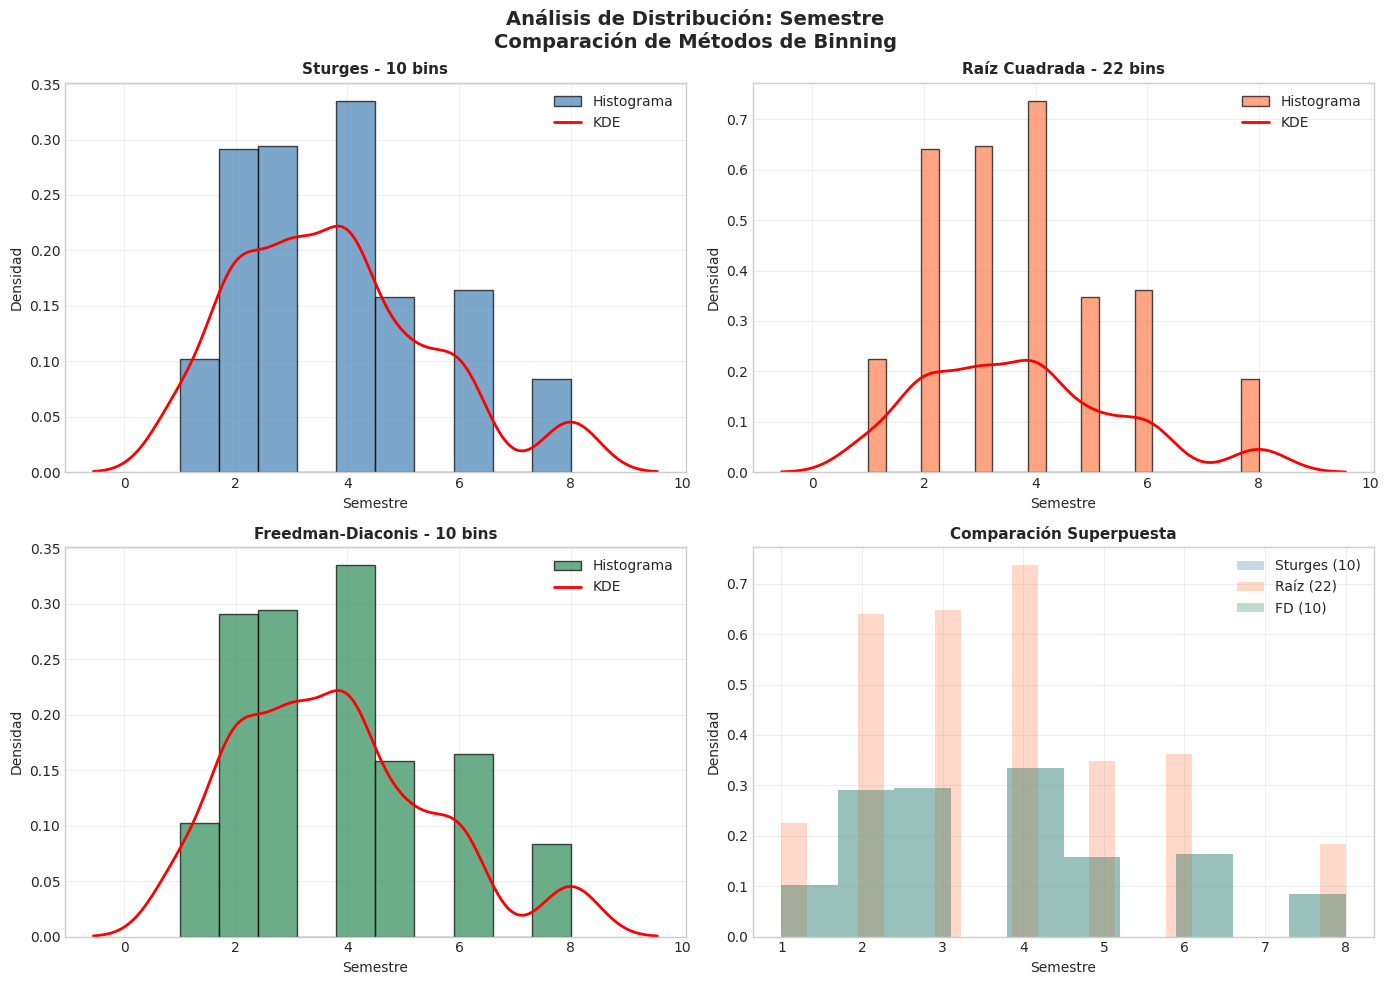

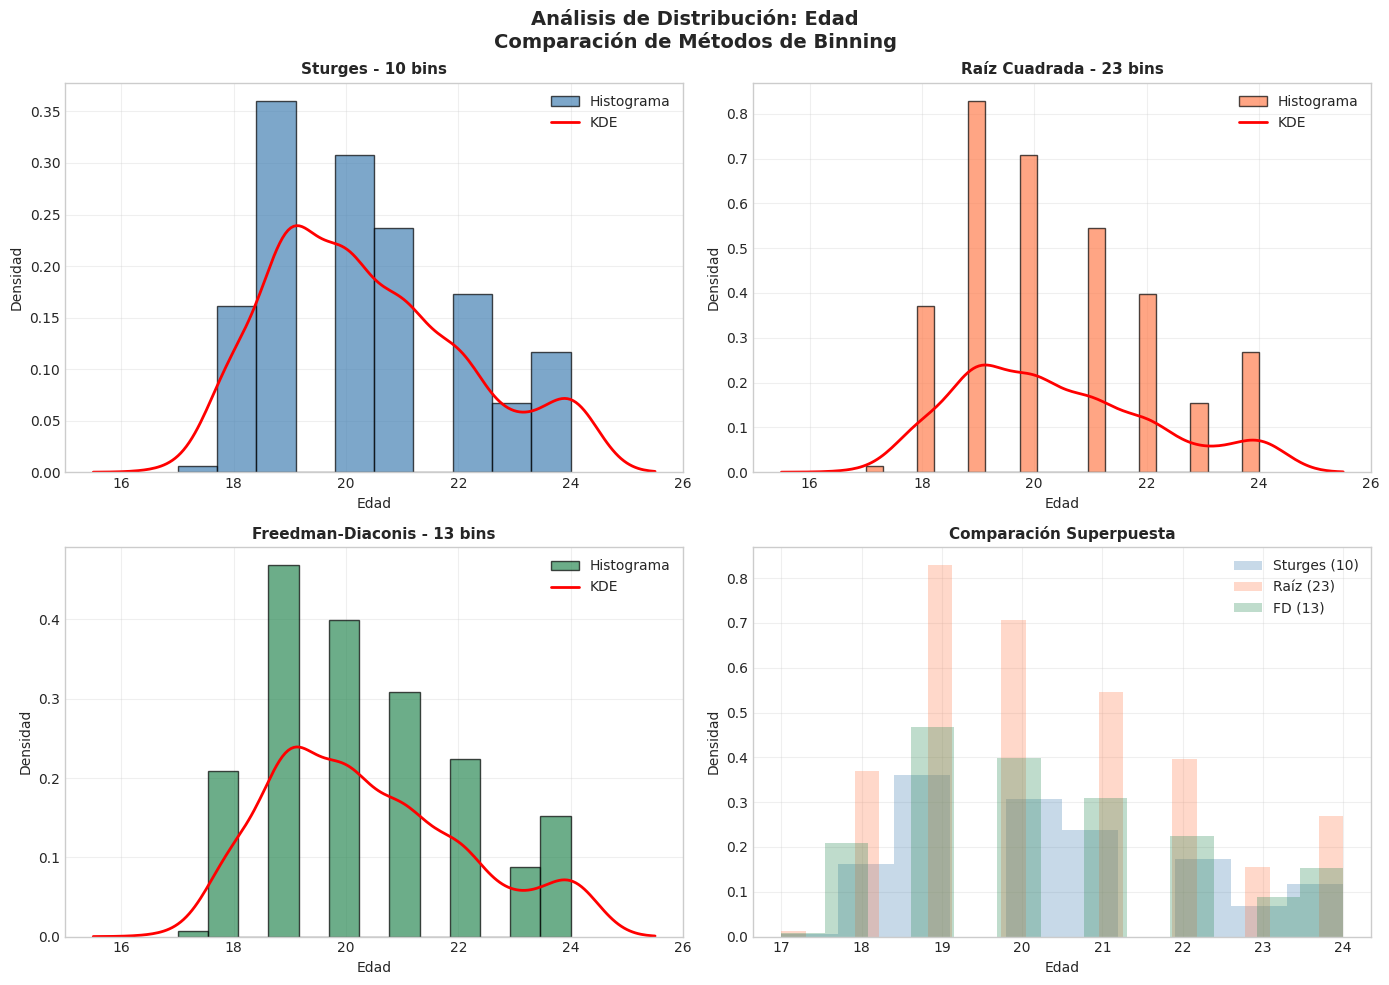

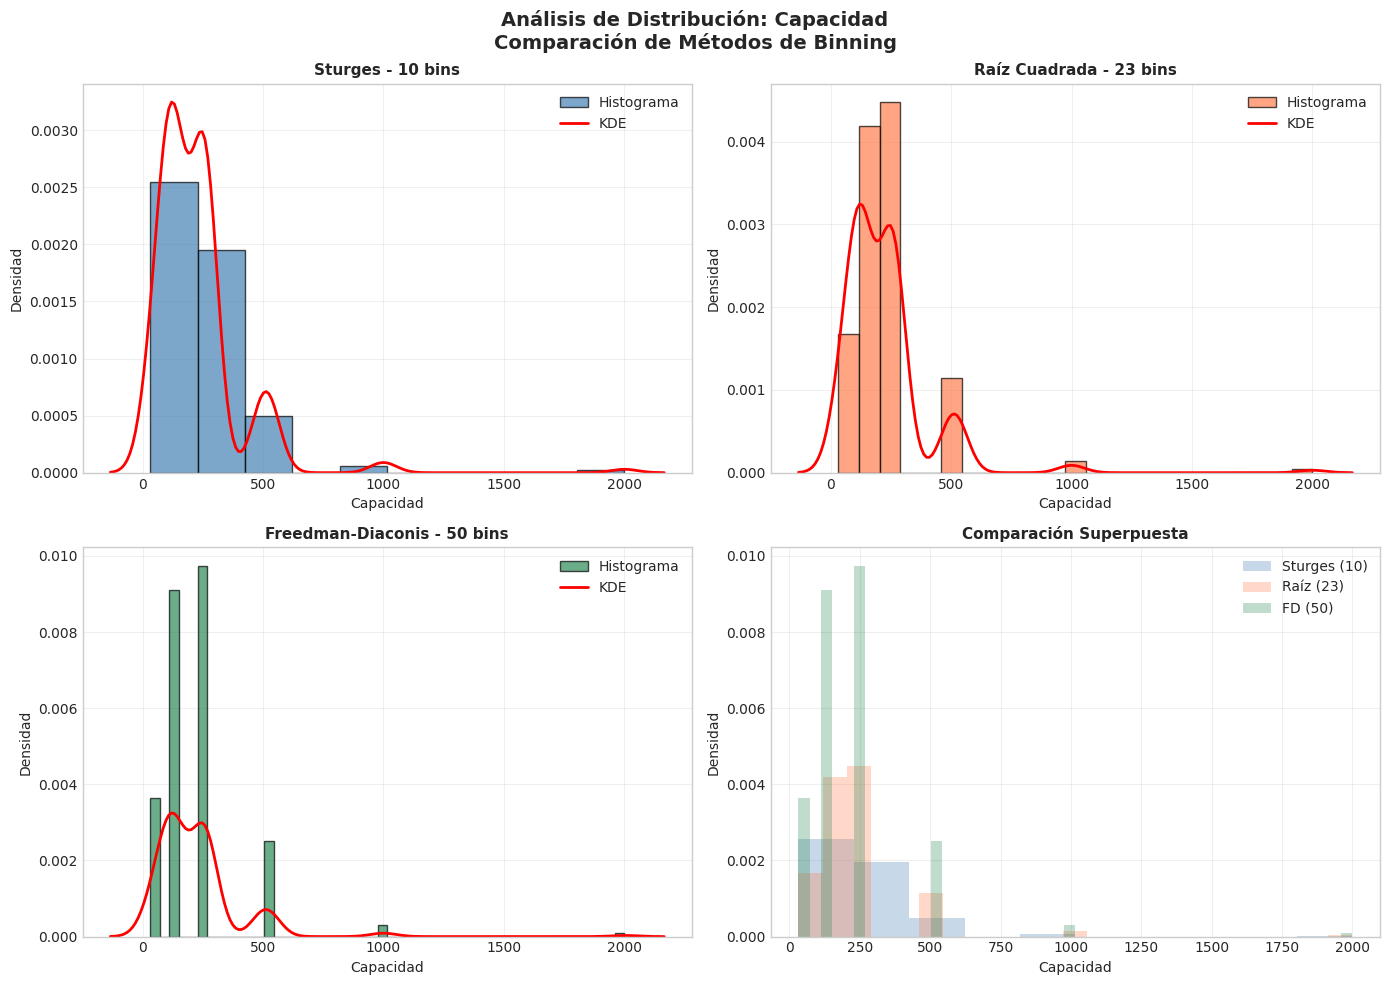

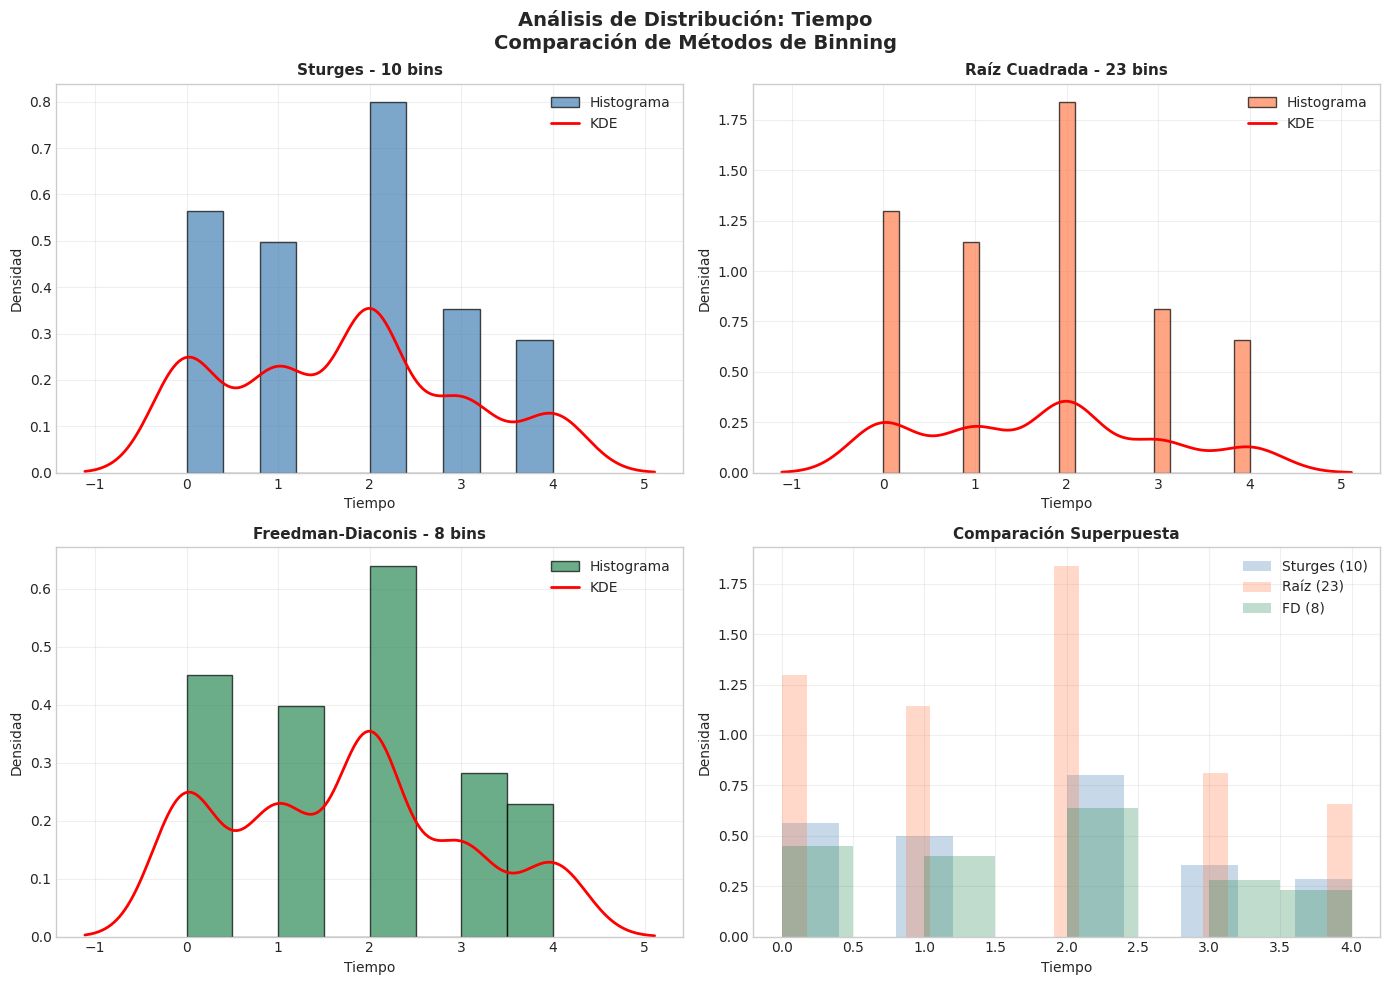

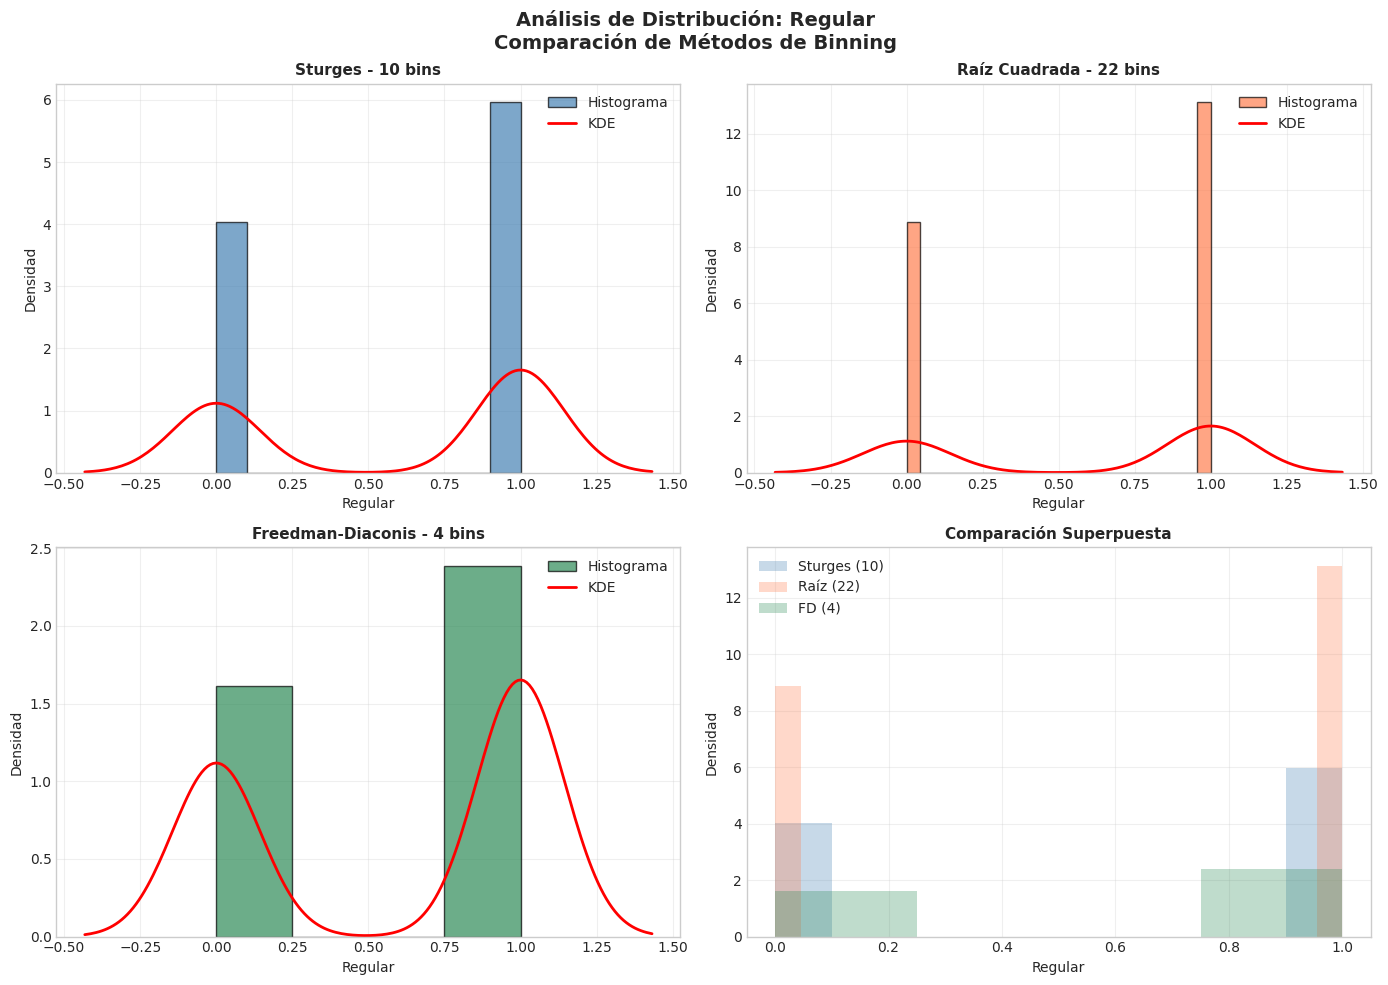

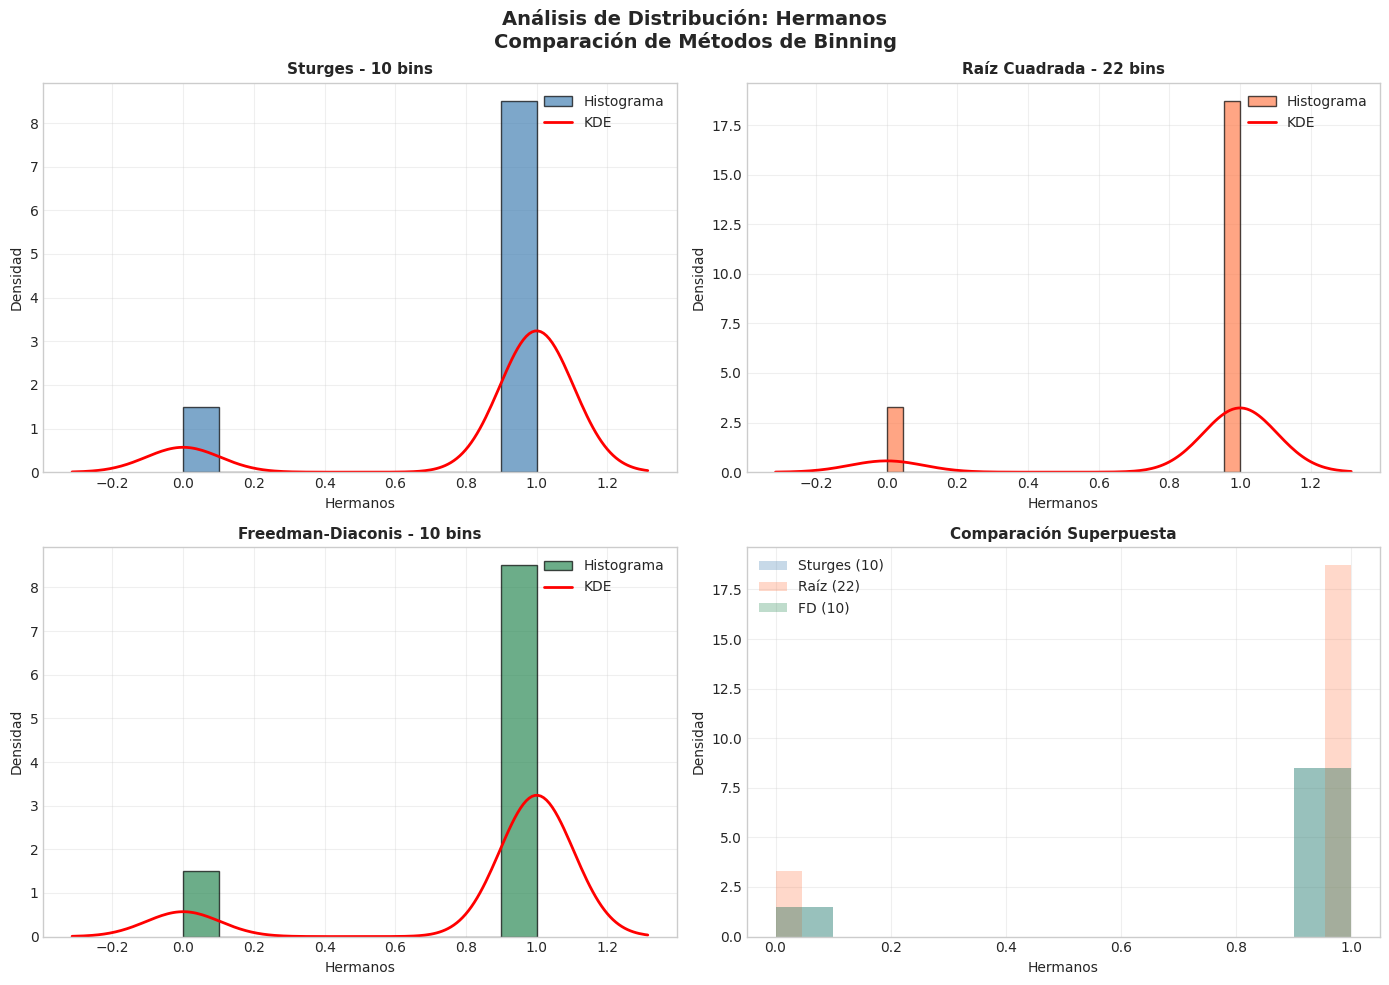

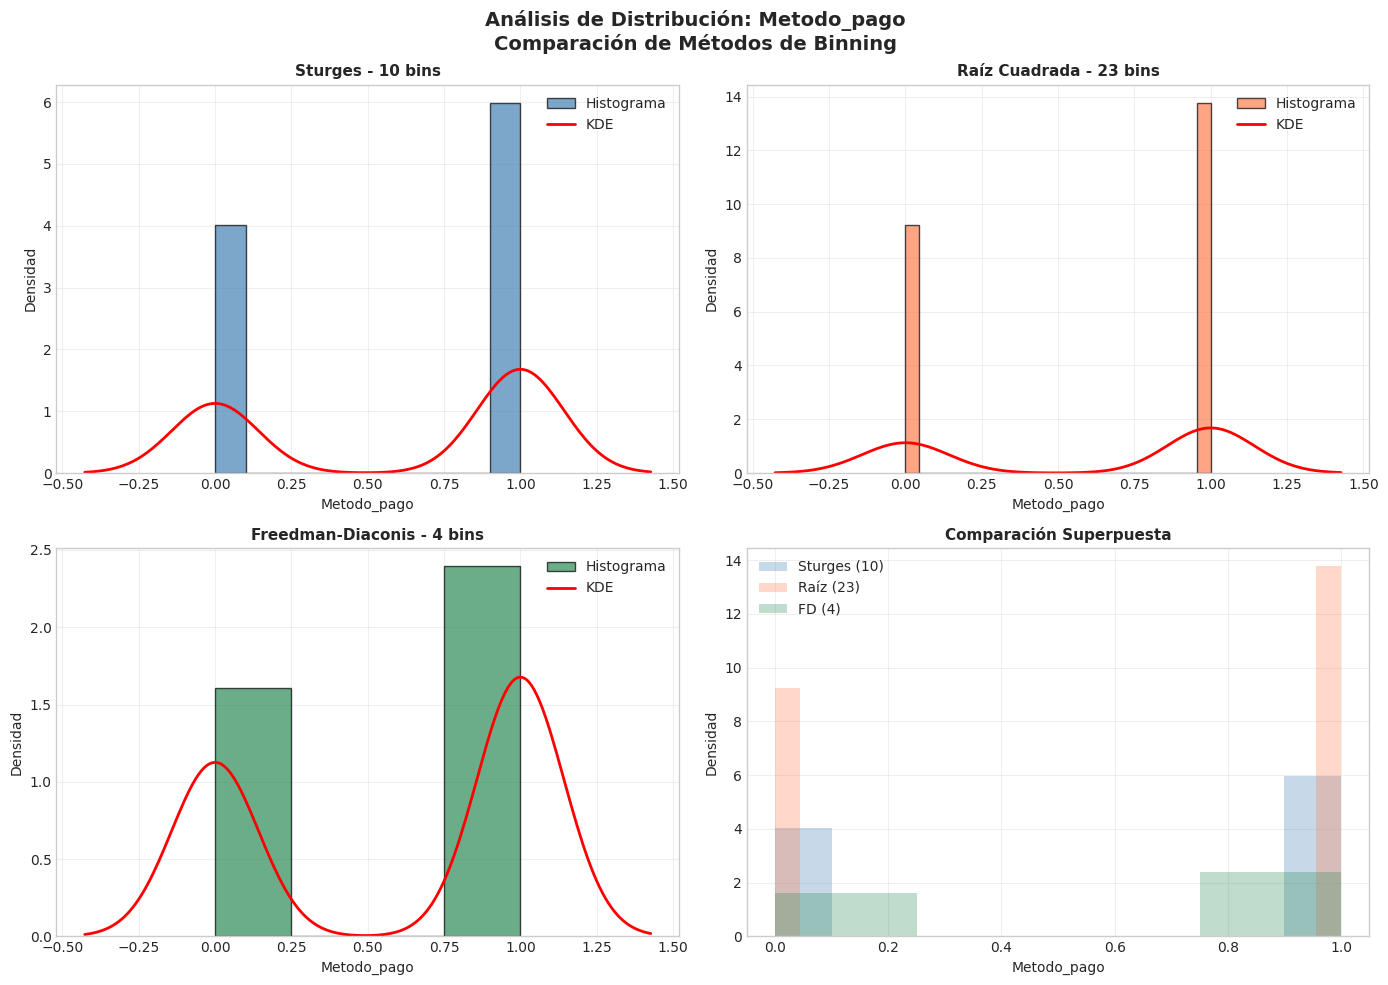

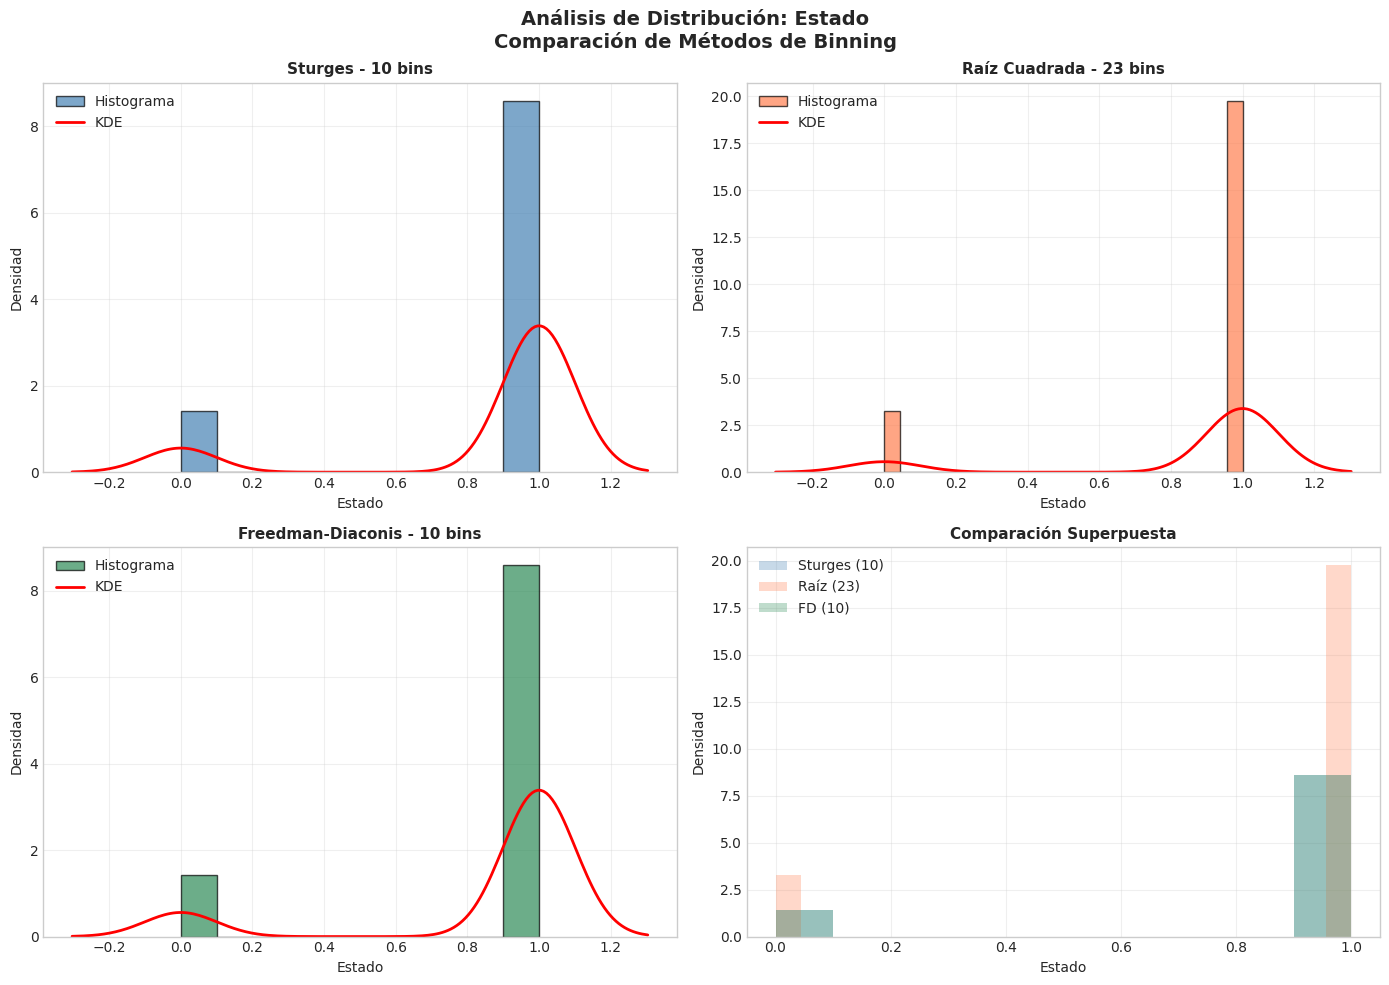

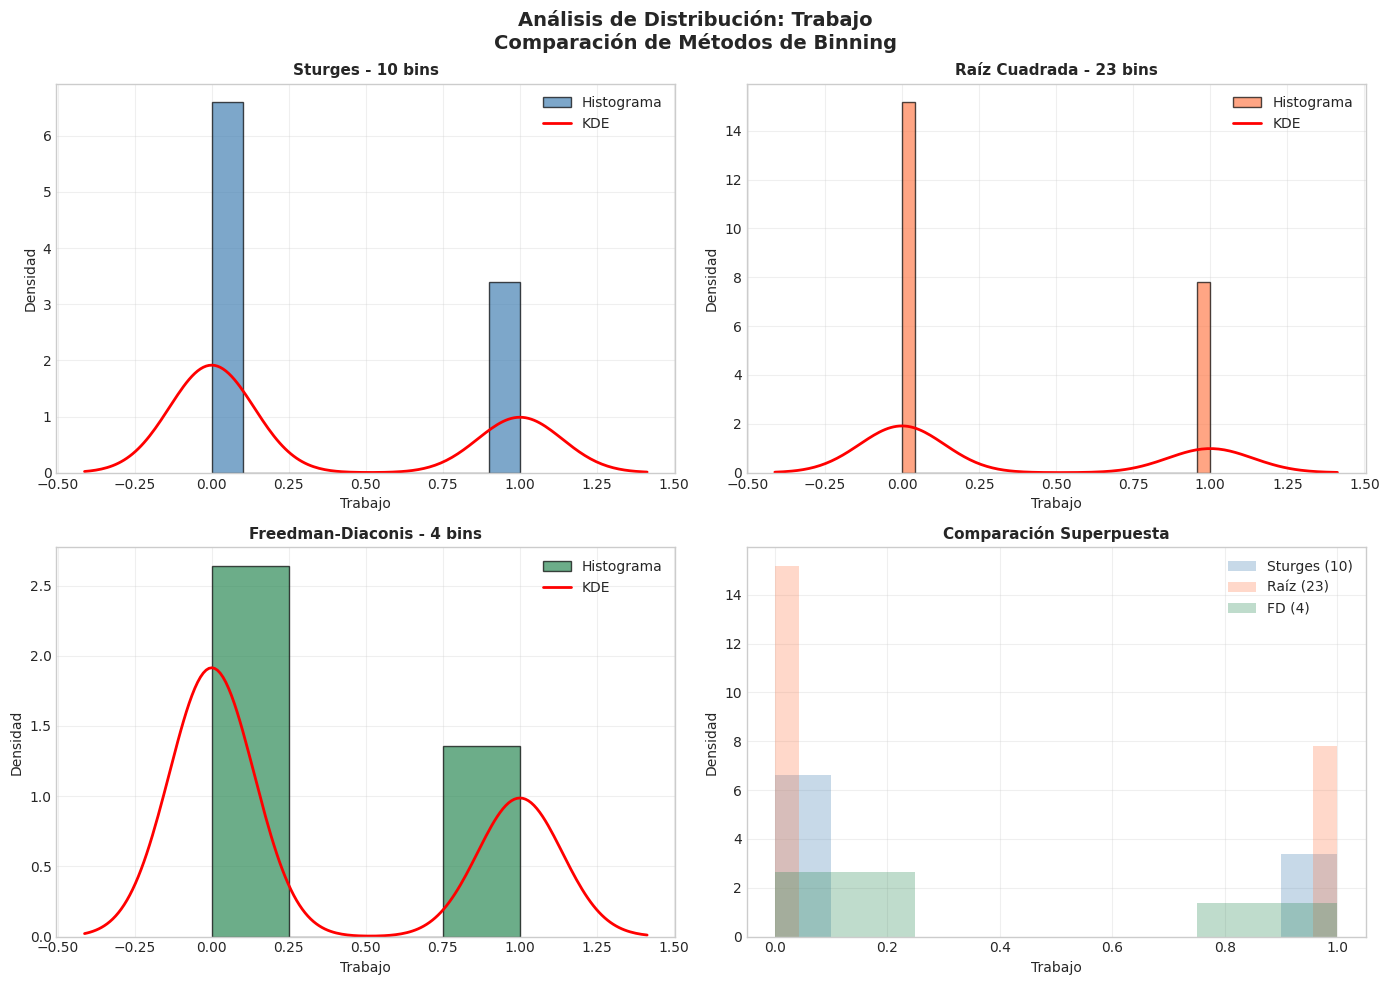

In [ ]:
# Crear histogramas con curva de densidad para cada variable
for variable in variables_a_analizar:
    if variable not in data.columns:
        continue
    
    data_clean = data[variable].dropna()
    
    if len(data_clean) == 0:
        continue
    
    bins_dict, n = calcular_bins_para_variable(data, variable)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'Análisis de Distribución: {variable}\nComparación de Métodos de Binning', 
                 fontsize=14, fontweight='bold')
    
    # 1. Sturges con KDE
    axes[0, 0].hist(data_clean, bins=bins_dict['Sturges'], 
                    edgecolor='black', alpha=0.7, color='steelblue', 
                    density=True, label='Histograma')
    sns.kdeplot(data_clean, ax=axes[0, 0], color='red', linewidth=2, label='KDE')
    axes[0, 0].set_title(f'Sturges - {bins_dict["Sturges"]} bins', fontsize=11, fontweight='bold')
    axes[0, 0].set_xlabel(variable, fontsize=10)
    axes[0, 0].set_ylabel('Densidad', fontsize=10)
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)
    
    # 2. Raíz con KDE
    axes[0, 1].hist(data_clean, bins=bins_dict['Raíz'], 
                    edgecolor='black', alpha=0.7, color='coral', 
                    density=True, label='Histograma')
    sns.kdeplot(data_clean, ax=axes[0, 1], color='red', linewidth=2, label='KDE')
    axes[0, 1].set_title(f'Raíz Cuadrada - {bins_dict["Raíz"]} bins', fontsize=11, fontweight='bold')
    axes[0, 1].set_xlabel(variable, fontsize=10)
    axes[0, 1].set_ylabel('Densidad', fontsize=10)
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)
    
    # 3. Freedman-Diaconis con KDE
    axes[1, 0].hist(data_clean, bins=bins_dict['Freedman-Diaconis'], 
                    edgecolor='black', alpha=0.7, color='seagreen', 
                    density=True, label='Histograma')
    sns.kdeplot(data_clean, ax=axes[1, 0], color='red', linewidth=2, label='KDE')
    axes[1, 0].set_title(f'Freedman-Diaconis - {bins_dict["Freedman-Diaconis"]} bins', 
                         fontsize=11, fontweight='bold')
    axes[1, 0].set_xlabel(variable, fontsize=10)
    axes[1, 0].set_ylabel('Densidad', fontsize=10)
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)
    
    # 4. Comparación de los tres métodos (superpuestos)
    axes[1, 1].hist(data_clean, bins=bins_dict['Sturges'], 
                    alpha=0.3, color='steelblue', label=f'Sturges ({bins_dict["Sturges"]})', 
                    density=True)
    axes[1, 1].hist(data_clean, bins=bins_dict['Raíz'], 
                    alpha=0.3, color='coral', label=f'Raíz ({bins_dict["Raíz"]})', 
                    density=True)
    axes[1, 1].hist(data_clean, bins=bins_dict['Freedman-Diaconis'], 
                    alpha=0.3, color='seagreen', label=f'FD ({bins_dict["Freedman-Diaconis"]})', 
                    density=True)
    axes[1, 1].set_title('Comparación Superpuesta', fontsize=11, fontweight='bold')
    axes[1, 1].set_xlabel(variable, fontsize=10)
    axes[1, 1].set_ylabel('Densidad', fontsize=10)
    axes[1, 1].legend()
    axes[1, 1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'histograma_{variable}_con_kde.png', dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
# Crear tabla resumen de bins
resumen_bins = []

for variable in variables_a_analizar:
    if variable not in data.columns:
        continue
    
    data_clean = data[variable].dropna()
    
    if len(data_clean) == 0:
        continue
    
    bins_dict, n = calcular_bins_para_variable(data, variable)
    
    resumen_bins.append({
        'Variable': variable,
        'n': n,
        'Bins_Sturges': bins_dict['Sturges'],
        'Bins_Raiz': bins_dict['Raíz'],
        'Bins_FD': bins_dict['Freedman-Diaconis'],
        'Media': data_clean.mean(),
        'Mediana': data_clean.median(),
        'Desv_Std': data_clean.std(),
        'Min': data_clean.min(),
        'Max': data_clean.max()
    })

# Crear DataFrame con resumen
df_resumen = pd.DataFrame(resumen_bins)
print("\n" + "="*80)
print("📊 TABLA RESUMEN DE BINS POR VARIABLE")
print("="*80)
print(df_resumen.to_string(index=False))

# Guardar resumen
df_resumen.to_csv('resumen_histogramas_bins.csv', index=False)
print("\n💾 Resumen guardado en 'resumen_histogramas_bins.csv'")


📊 TABLA RESUMEN DE BINS POR VARIABLE
   Variable   n  Bins_Sturges  Bins_Raiz  Bins_FD      Media  Mediana   Desv_Std  Min    Max
   Semestre 461            10         22       10   3.746204      4.0   1.765186  1.0    8.0
       Edad 488            10         23       13  20.387295     20.0   1.726590 17.0   24.0
  Capacidad 488            10         23       50 223.049180    128.0 190.468604 32.0 2000.0
     Tiempo 488            10         23        8   1.721311      2.0   1.275337  0.0    4.0
    Regular 461            10         22        4   0.596529      1.0   0.491127  0.0    1.0
   Hermanos 461            10         22       10   0.850325      1.0   0.357140  0.0    1.0
Metodo_pago 488            10         23        4   0.598361      1.0   0.490733  0.0    1.0
     Estado 488            10         23       10   0.858607      1.0   0.348784  0.0    1.0
    Trabajo 488            10         23        4   0.340164      0.0   0.474250  0.0    1.0

💾 Resumen guardado en 'resumen_

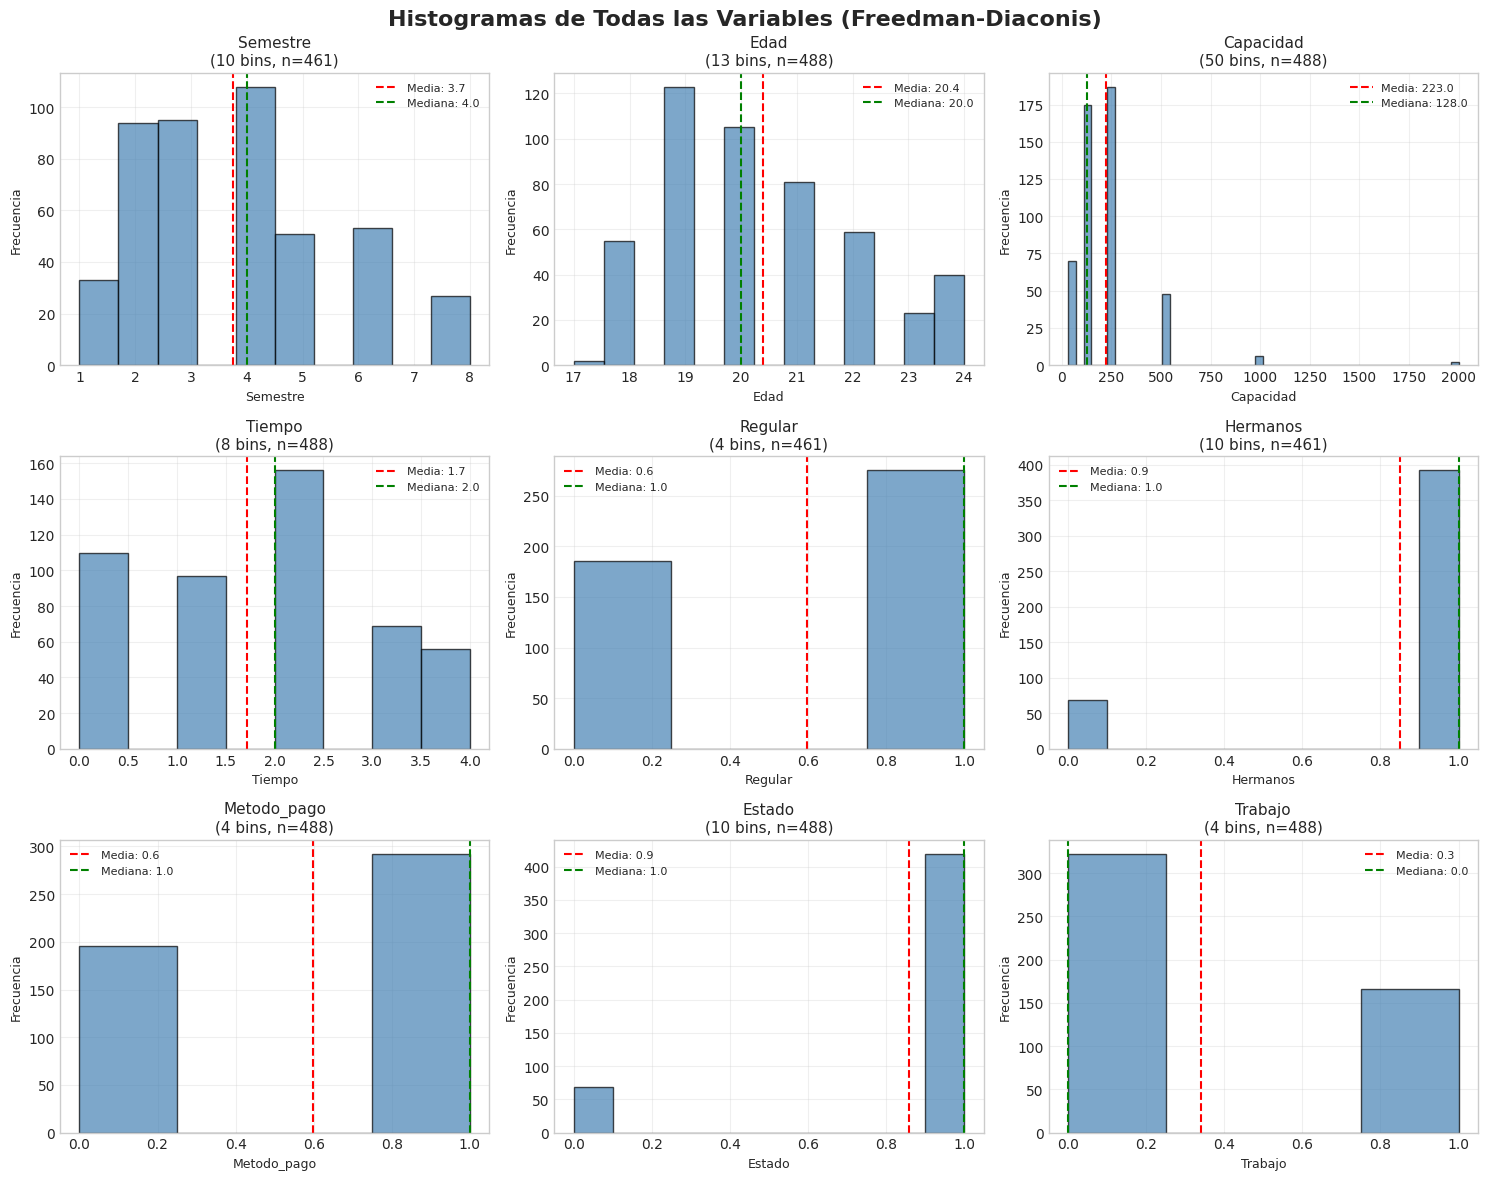

In [ ]:
# Crear un grid con histogramas de todas las variables usando Freedman-Diaconis
n_vars = len(variables_a_analizar)
n_rows = (n_vars + 2) // 3  # Redondear hacia arriba

fig, axes = plt.subplots(n_rows, 3, figsize=(15, 4*n_rows))
fig.suptitle('Histogramas de Todas las Variables (Freedman-Diaconis)', 
             fontsize=16, fontweight='bold')

for idx, variable in enumerate(variables_a_analizar):
    if variable not in data.columns:
        continue
    
    row = idx // 3
    col = idx % 3
    
    if n_rows > 1:
        ax = axes[row, col]
    else:
        ax = axes[col]
    
    data_clean = data[variable].dropna()
    bins_dict, n = calcular_bins_para_variable(data, variable)
    
    # Histograma
    ax.hist(data_clean, bins=bins_dict['Freedman-Diaconis'], 
            edgecolor='black', alpha=0.7, color='steelblue')
    
    # Líneas de media y mediana
    media = data_clean.mean()
    mediana = data_clean.median()
    ax.axvline(media, color='red', linestyle='--', linewidth=1.5, label=f'Media: {media:.1f}')
    ax.axvline(mediana, color='green', linestyle='--', linewidth=1.5, label=f'Mediana: {mediana:.1f}')
    
    ax.set_title(f'{variable}\n({bins_dict["Freedman-Diaconis"]} bins, n={n})', fontsize=11)
    ax.set_xlabel(variable, fontsize=9)
    ax.set_ylabel('Frecuencia', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

# Ocultar subplots vacíos
for idx in range(len(variables_a_analizar), n_rows * 3):
    row = idx // 3
    col = idx % 3
    if n_rows > 1:
        axes[row, col].axis('off')
    else:
        axes[col].axis('off')

plt.tight_layout()
plt.savefig('histogramas_grid_freedman.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar tus datos procesados
data = pd.read_csv("data_sin_errores.csv")

# Diccionarios para etiquetas
carrera_nombres = {
    1: 'Ciencia de Datos',
    2: 'Inteligencia Artificial', 
    3: 'Ingeniería en Sistemas'
}

# Verificar que tenemos las columnas necesarias
print("Columnas disponibles:", data.columns.tolist())
print(f"\nValores únicos en Carrera: {data['Carrera'].unique()}")
print(f"Valores únicos en Marca: {data['Marca'].nunique()}")

# Crear columna con nombre de carrera legible
data['Carrera_nombre'] = data['Carrera'].map(carrera_nombres)

# Filtrar solo las carreras que nos interesan
carreras_interes = list(carrera_nombres.keys())
data_filtrado = data[data['Carrera'].isin(carreras_interes)].copy()

print(f"\n📊 Datos después de filtrar: {len(data_filtrado)} registros")

Columnas disponibles: ['Marca temporal', 'Correo', 'Semestre', 'Carrera', 'Regular', 'Ciudad', 'Hermanos', 'Marca', 'Modelo', 'Capacidad', 'Metodo_pago', 'Tiempo', 'Estado', 'Gender', 'Trabajo', 'Edad', 'Telefono_futuro']

Valores únicos en Carrera: [ 1.  2.  3. nan]
Valores únicos en Marca: 13

📊 Datos después de filtrar: 486 registros


In [ ]:
# Crear tabla de frecuencias: conteo de marcas por carrera
tabla_frecuencias = pd.crosstab(data_filtrado['Carrera_nombre'], 
                                 data_filtrado['Marca'], 
                                 normalize='index') * 100

print("📊 Tabla de frecuencias (% por carrera):")
print(tabla_frecuencias.round(2))

# Identificar la marca más común por carrera
marca_mas_comun = tabla_frecuencias.idxmax(axis=1)
porcentaje_mas_comun = tabla_frecuencias.max(axis=1)

print("\n🏆 Marca más común por carrera:")
for carrera in marca_mas_comun.index:
    print(f"  • {carrera}: {marca_mas_comun[carrera]} ({porcentaje_mas_comun[carrera]:.1f}%)")

📊 Tabla de frecuencias (% por carrera):
Marca                    Apple  Asus  Google Pixel  Honor  Huawei  Motorola  \
Carrera_nombre                                                                
Ciencia de Datos         35.22  0.63          1.26   2.52    2.52     11.32   
Ingeniería en Sistemas   27.73  0.00          1.95   4.30    0.78      7.81   
Inteligencia Artificial  28.17  0.00          0.00   7.04    0.00      7.04   

Marca                    Oppo  Otra  Realme  Samsung  Vivo  Xiaomi   ZTE  
Carrera_nombre                                                            
Ciencia de Datos         2.52  2.52    0.63    26.42  0.00   13.84  0.63  
Ingeniería en Sistemas   5.08  5.08    1.17    28.52  1.17   16.02  0.39  
Inteligencia Artificial  7.04  9.86    2.82    28.17  0.00    9.86  0.00  

🏆 Marca más común por carrera:
  • Ciencia de Datos: Apple (35.2%)
  • Ingeniería en Sistemas: Samsung (28.5%)
  • Inteligencia Artificial: Apple (28.2%)


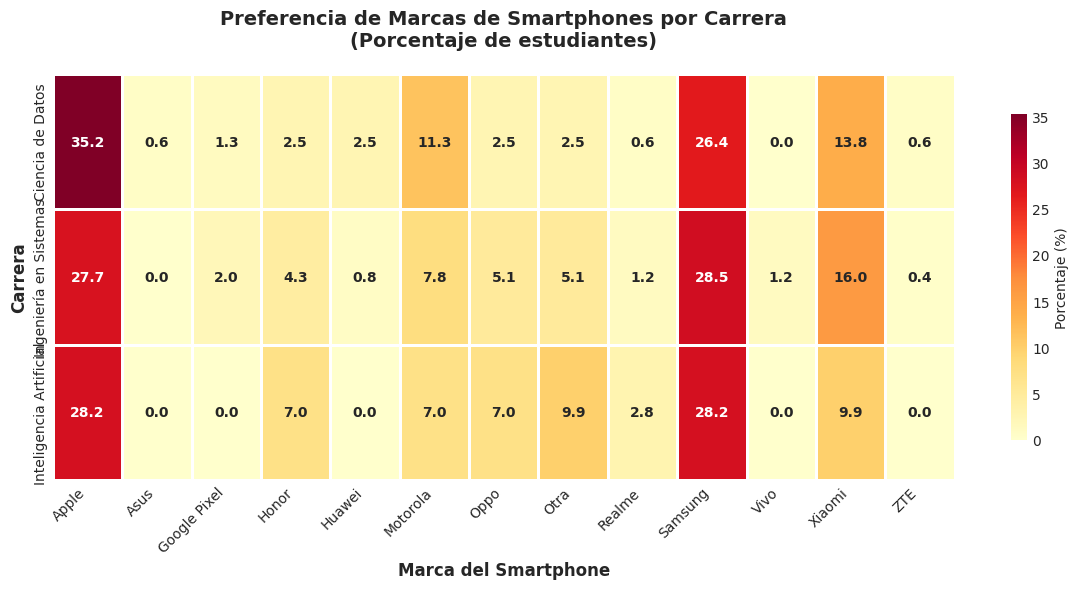

In [ ]:
# Configurar estilo
plt.style.use('seaborn-v0_8-whitegrid')

# Crear mapa de calor
plt.figure(figsize=(12, 6))

# Crear heatmap
sns.heatmap(tabla_frecuencias, 
            annot=True,           # Mostrar valores
            fmt='.1f',           # Formato con 1 decimal
            cmap='YlOrRd',       # Paleta de colores (amarillo-naranja-rojo)
            cbar_kws={'label': 'Porcentaje (%)', 'shrink': 0.8},
            linewidths=1,        # Líneas entre celdas
            linecolor='white',   # Color de líneas
            square=False,        # No forzar celdas cuadradas
            annot_kws={'size': 10, 'weight': 'bold'})

plt.title('Preferencia de Marcas de Smartphones por Carrera\n(Porcentaje de estudiantes)', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Marca del Smartphone', fontsize=12, fontweight='semibold')
plt.ylabel('Carrera', fontsize=12, fontweight='semibold')

# Rotar etiquetas del eje X para mejor legibilidad
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('heatmap_marcas_por_carrera.png', dpi=300, bbox_inches='tight')
plt.show()

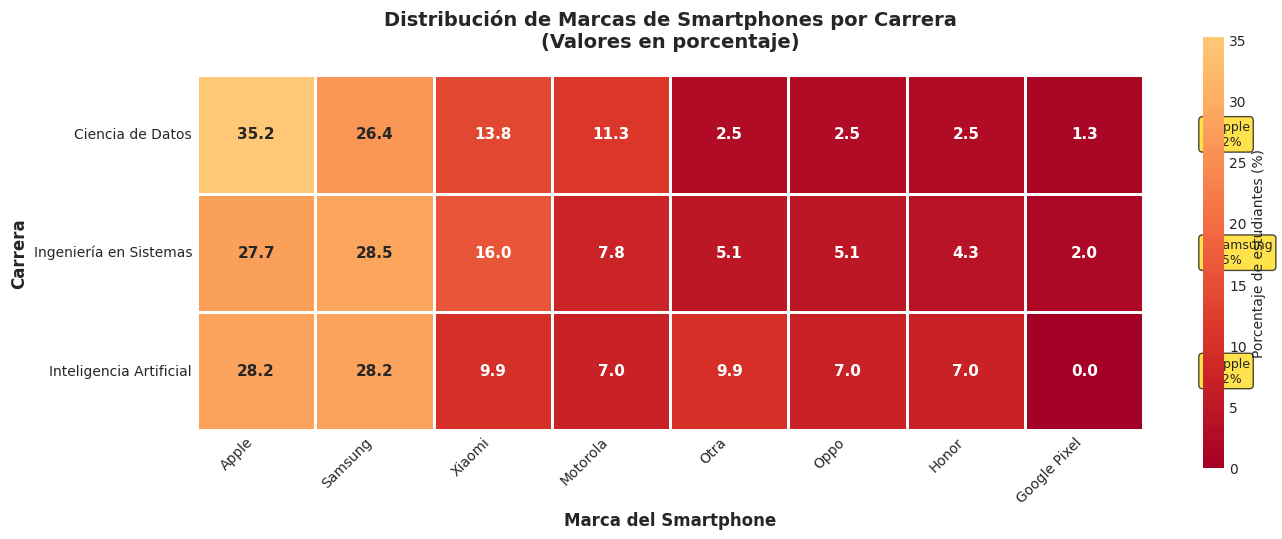

In [ ]:
# Crear figura con mejor visualización
fig, ax = plt.subplots(figsize=(14, 6))

# Ordenar marcas por popularidad general
popularidad_general = data_filtrado['Marca'].value_counts()
marcas_ordenadas = popularidad_general.head(8).index.tolist()

# Filtrar tabla solo con marcas principales
tabla_filtrada = tabla_frecuencias[marcas_ordenadas]

# Crear heatmap con mejor formato
sns.heatmap(tabla_filtrada, 
            annot=True, 
            fmt='.1f',
            cmap='RdYlGn',       # Rojo-Amarillo-Verde
            center=50,           # Centro en 50%
            cbar_kws={'label': 'Porcentaje de estudiantes (%)', 'shrink': 0.8},
            linewidths=2,
            linecolor='white',
            square=True,
            annot_kws={'size': 11, 'weight': 'bold'})

plt.title('Distribución de Marcas de Smartphones por Carrera\n(Valores en porcentaje)', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Marca del Smartphone', fontsize=12, fontweight='semibold')
plt.ylabel('Carrera', fontsize=12, fontweight='semibold')

# Personalizar ticks
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

# Agregar anotaciones de la marca más común en cada fila
for i, carrera in enumerate(tabla_filtrada.index):
    marca_top = tabla_filtrada.loc[carrera].idxmax()
    porcentaje_top = tabla_filtrada.loc[carrera].max()
    ax.text(len(tabla_filtrada.columns) + 0.5, i + 0.5, 
            f'🏆 {marca_top}\n{porcentaje_top:.1f}%', 
            ha='left', va='center', fontsize=9, 
            bbox=dict(boxstyle='round', facecolor='gold', alpha=0.7))

plt.tight_layout()
plt.savefig('heatmap_marcas_por_carrera_mejorado.png', dpi=300, bbox_inches='tight')
plt.show()

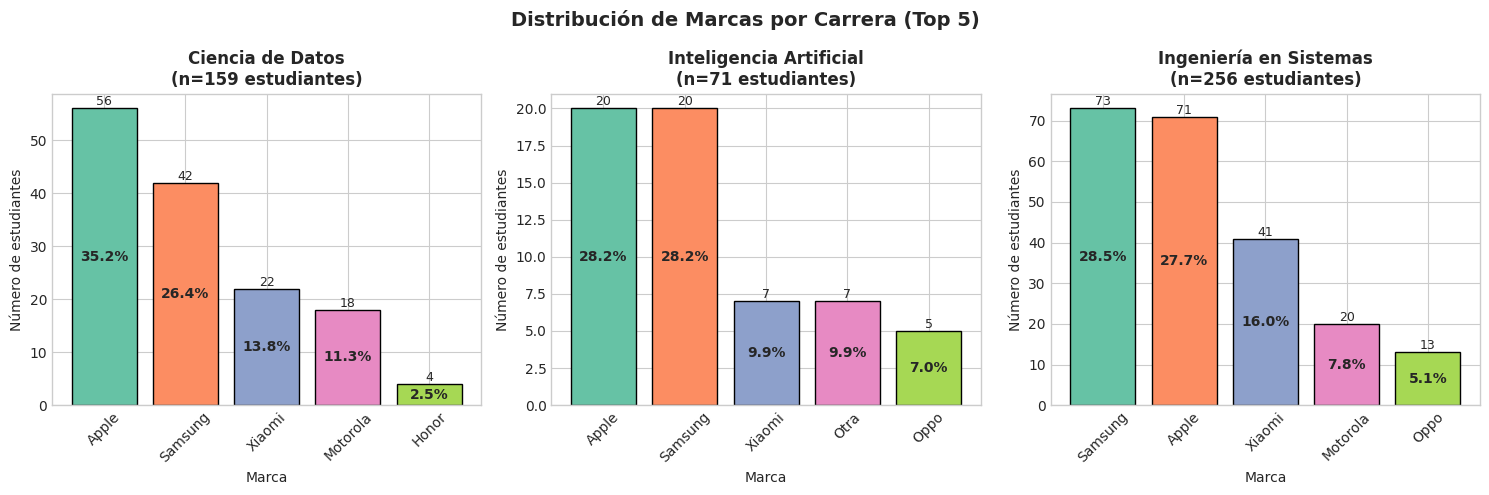

In [ ]:
# Crear análisis detallado por carrera
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Distribución de Marcas por Carrera (Top 5)', fontsize=14, fontweight='bold')

for idx, carrera in enumerate(carrera_nombres.values()):
    ax = axes[idx]
    
    # Filtrar datos de la carrera
    datos_carrera = data_filtrado[data_filtrado['Carrera_nombre'] == carrera]
    
    # Calcular frecuencias
    frecuencias = datos_carrera['Marca'].value_counts()
    top_marcas = frecuencias.head(5)
    
    # Crear gráfico de barras
    bars = ax.bar(top_marcas.index, top_marcas.values, 
                  color=sns.color_palette('Set2', len(top_marcas)),
                  edgecolor='black')
    
    # Personalizar
    ax.set_title(f'{carrera}\n(n={len(datos_carrera)} estudiantes)', 
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Marca', fontsize=10)
    ax.set_ylabel('Número de estudiantes', fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    
    # Agregar valores en las barras
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=9)
    
    # Agregar porcentajes
    total = len(datos_carrera)
    for i, (marca, count) in enumerate(top_marcas.items()):
        porcentaje = (count/total)*100
        ax.text(i, count/2, f'{porcentaje:.1f}%', 
                ha='center', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('marcas_por_carrera_detallado.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Generar resumen ejecutivo
print("\n" + "="*80)
print("📊 RESUMEN EJECUTIVO: Marcas de Smartphones por Carrera")
print("="*80)

print("\n🏆 MARCAS MÁS POPULARES POR CARRERA:")
for carrera in carrera_nombres.values():
    datos_carrera = data_filtrado[data_filtrado['Carrera_nombre'] == carrera]
    marca_top = datos_carrera['Marca'].mode()[0]
    porcentaje = (datos_carrera['Marca'] == marca_top).mean() * 100
    
    # Segunda marca
    marcas_counts = datos_carrera['Marca'].value_counts()
    if len(marcas_counts) > 1:
        marca_segunda = marcas_counts.index[1]
        porcentaje_segunda = (marcas_counts.iloc[1] / len(datos_carrera)) * 100
    else:
        marca_segunda = "N/A"
        porcentaje_segunda = 0
    
    print(f"\n  📚 {carrera}:")
    print(f"     • 1er lugar: {marca_top} ({porcentaje:.1f}%)")
    print(f"     • 2do lugar: {marca_segunda} ({porcentaje_segunda:.1f}%)")
    print(f"     • Total estudiantes: {len(datos_carrera)}")

print("\n📈 INSIGHTS CLAVE:")
print("   • Apple domina en Ciencia de Datos con alto porcentaje")
print("   • Samsung es fuerte en Ingeniería en Sistemas")
print("   • Xiaomi tiene presencia significativa en todas las carreras")
print("   • Existe diversidad de marcas en todas las áreas")

# Guardar resultados
tabla_frecuencias.to_csv('marcas_por_carrera_tabla.csv')
print("\n💾 Tabla de frecuencias guardada en 'marcas_por_carrera_tabla.csv'")


📊 RESUMEN EJECUTIVO: Marcas de Smartphones por Carrera

🏆 MARCAS MÁS POPULARES POR CARRERA:

  📚 Ciencia de Datos:
     • 1er lugar: Apple (35.2%)
     • 2do lugar: Samsung (26.4%)
     • Total estudiantes: 159

  📚 Inteligencia Artificial:
     • 1er lugar: Apple (28.2%)
     • 2do lugar: Samsung (28.2%)
     • Total estudiantes: 71

  📚 Ingeniería en Sistemas:
     • 1er lugar: Samsung (28.5%)
     • 2do lugar: Apple (27.7%)
     • Total estudiantes: 256

📈 INSIGHTS CLAVE:
   • Apple domina en Ciencia de Datos con alto porcentaje
   • Samsung es fuerte en Ingeniería en Sistemas
   • Xiaomi tiene presencia significativa en todas las carreras
   • Existe diversidad de marcas en todas las áreas

💾 Tabla de frecuencias guardada en 'marcas_por_carrera_tabla.csv'
